# Statistical Machine Translation Tutorial (without Normalization)
Ye Kyaw Thu, Lab Leader, Language Understanding Lab., Myanmar  
For AI Fundamental Class students  
Date: 26 April 2026  

## Data


In [1]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial'

In [3]:
%cd clean-data/big/

/home/ye/exp/SMT-NMT_tutorial/clean-data/big


In [4]:
!ls *.my

dev.my	test.my  train.my


In [5]:
!ls *.th

dev.th	test.th  train.th


In [8]:
!wc *.my

  10000  117871 1126953 dev.my
   8000   93908  896405 test.my
  62625  734667 7029308 train.my
  80625  946446 9052666 total


In [9]:
!wc *.th

  10000   71013  825957 dev.th
   8000   56113  651909 test.th
  62625  439436 5110712 train.th
  80625  566562 6588578 total


ဒေတာ format ကတော့ စာကြောင်းတစ်ကြောင်းစီကို လိုင်းတစ်လိုင်းစီ ထားတဲ့ ပုံစံပါ။ အရေးကြီးတာက မြန်မာစာ နဲ့ ထိုင်းစာ ဘက်အခြမ်းက parallel corpus ဖြစ်နေမှ ရပါမယ်။  

In [10]:
!head train.th

คือ มี อาการ อย่าง ใด อย่าง หนึ่ง ต่อ ไป นี้
ใจเย็น ๆ ก่อน นะ คะ
ไม่ มี โรค ประจำ ตัว
อาการ เบื้อง ต้น
แล้ว เอา หู ฟัง วาง ตรงเหนือ ข้อ พับ ตรง นี้ นิด นึง นะ คะ
ผม กิน ไอ พวก กุ้ง
แต่ว่า
ผม ควร ประคบ น้ำ แข็ง บน หัว ไหม
เดี๋ยว รบกวน ไป ตรวจรังสี คอมพิวเตอร์ นิด นึง นะ ครับ
ระหว่าง นี้ นั่ง รอ ตรง นั้น ก่อน นะ ครับ


In [11]:
!head train.my

အောက် ပါ ရော ဂါ လက္ခ ဏာ တွေ များ ရှိ ရင်
စိတ် ကို အေး အေး ဆေး ဆေး ထား ပါ
နာ တာ ရှည် ရော ဂါ ရယ် လို့ မ ရှိ ပါ ဘူး ဗျ
လက္ခ ဏာ တွေ နဲ့
ပြီး တဲ့ အ ခါ နား ကြပ် ကို တံ တော င့် ဆစ် နား မှာ ထား မှာ မို့ ပါ ရှင်
ပု စွန် တော့ ကျွန် တော် စား တယ်
သို့ ပေ မဲ့ လည်း
ကျွန် တော် ခေါင်း ပေါ် ရေ ခဲ တင် ထား ရ မ လား
ကွန် ပြူ တာ ရောင် ခြည် နဲ့ ထပ် စစ် ဆေး ပါ မယ် နော်
ဒီ ကြား မှာ ခ ဏ လေး ထိုင် စော င့် ပေး လို့ ရ မ လား


In [13]:
!tail test.th

อ๋อ
ตัว แข็ง มา ค่ะ
ต้อง อยู่ ภาย ใต้ การ ดูแล อย่าง ใกล้ชิด ของ แพทย์ และ ผู้ เชี่ยวชาญ
ตำแหน่ง ที่ ปวด เป็น ตรง ไหน บ้าง
ฝาก ครรภ์
ผม ไม่ ขับ รถ ไป สัก พัก เลย ครับ
ไม่ มี ใคร เคย ถาม ว่า หนู เป็น อะไร ด้วยซ้ำ
มี อาการ อื่น ๆ อีก ไหม ครับ
ตาม ที่ หมอ เคย อธิบาย
นิ่ง ไว้ นะ คะ อย่า ขยับ จนกว่า จะ เดิน เข้า มา เอา ที่ กัด ออก ให้ นะ คะ


In [12]:
!tail test.my

အမ်
ခန္ဓာ ကိုယ် က မာ တော င့် နေ တယ် ရှ င့်
ဆ ရာ ဝန် တွေ ရော အ ထူး ကု တွေ နဲ့ ပါ ကု သ တာ
ဘယ် နား က နာ တာ လဲ ရှင်
ကိုယ် ဝန် ကို အပ် ထား ပါ
ကျွန် တော် အ တော် ကြာ ကား မ မောင်း ခဲ့ ဘူး
ဘယ် သူ က မှ လည်း သ မီး ဘာ ဖြစ် နေ တာ လဲ လို့ မ မေး ကြ ဘူး
အ ခြား ဘာ လက္ခ ဏာ တွေ ဖြစ် သေး လဲ
ဒေါက် တာ ဒီ ကိစ္စ ကို ဟိုး အ ရင် က ပြော ပြ ဖူး ပါ တယ်
သွား နဲ့ ကိုက် ထား တဲ့ ဟာ လာ မ ထုတ် မ ချင်း ငြိမ် နေ ပေး ပါ လုံး ဝ မ လှုပ် ပါ နဲ့ ရှင်


ဒီတစ်ခါတော့ အတန်းထဲမှာ run ပြခဲ့သလို ဒေတာ နည်းနည်းကို မသုံးပဲ အပြည့်သုံးပြီး run ပါမယ်။
Moses ရဲ့ experimental management framework ရဲ့ config ကို သုံးမှာမို့လို့ test ဒေတာကိုလည်း SGM format ပြောင်းထားဖို့ လိုအပ်ပါတယ်။ ပြောင်းထားပြီးပါပြီ။ အောက်ပါအတိုင်းပါ။  

In [15]:
!tree .

.
├── dev.my
├── dev.th
├── test.my
├── test-sgm
│   ├── generate_sgms.pl
│   ├── ref2sgm.pl
│   ├── src2sgm.pl
│   ├── test.my.ref.sgm
│   ├── test.my.src.sgm
│   ├── test.th.ref.sgm
│   └── test.th.src.sgm
├── test.th
├── train.my
└── train.th

2 directories, 13 files


**SGM format က အောက်ပါအတိုင်းပါ။**  

In [16]:
!head ./test-sgm/test.my.src.sgm

<srcset setid="Thai-Myanmar_data" srclang="any">
<doc docid="none" genre="8000" origlang="my">
<seg id="1">ခွဲ မှ ရ မှာ လား </seg>
<seg id="2">မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် </seg>
<seg id="3">အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် </seg>
<seg id="4">ဟုတ် ကဲ့ သူ ဖျား ပါ တယ် သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး </seg>
<seg id="5">မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ </seg>
<seg id="6">ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ် </seg>
<seg id="7">မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင် </seg>
<seg id="8">အ ချို ကို လျော့ ချ ကြ ည့် လိုက် ပါ </seg>


In [17]:
!head ./test-sgm/test.th.src.sgm

<srcset setid="Thai-Myanmar_data" srclang="any">
<doc docid="none" genre="8000" origlang="th">
<seg id="1">ต้อง ผ่าตัด ไหม </seg>
<seg id="2">หนัง ตา กระตุก </seg>
<seg id="3">คุณ ควร งด แอลกอฮอล์ และ รับประทาน อาหาร ที่ มี ประโยชน์ ซึ่ง อุดม ไป ด้วย โปรตีน และ วิตามิน </seg>
<seg id="4">เธอ ป่วย ค่ะ และ เธอ ไม่ ได้ กัก ตัว ค่ะ </seg>
<seg id="5">น้องทาน ยา ครั้ง สุดท้าย เมื่อ ไหร่ คะ </seg>
<seg id="6">แนวโน้ม ที่ ร่างกาย ติด เชื้อ บาดเจ็บ ต่อ สมอง </seg>
<seg id="7">เรียก ญาติ คุณปราโมท เข้า มา ให้ หน่อย ค่ะ </seg>
<seg id="8">ลด ปริมาน ของ หวาน มัน </seg>


**Source အပိုင်းကို ကြည့်ပြီးသွားပြီ။ Reference အပိုင်းကိုလည်း လေ့လာကြည့်ရအောင်။**  

In [18]:
!head ./test-sgm/test.my.ref.sgm

<refset trglang="my" setid="Thai-Myanmar_data" srclang="any">
<doc sysid="ref" docid="none" genre="8000" origlang="any">
<seg id="1">ခွဲ မှ ရ မှာ လား </seg>
<seg id="2">မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် </seg>
<seg id="3">အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် </seg>
<seg id="4">ဟုတ် ကဲ့ သူ ဖျား ပါ တယ် သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး </seg>
<seg id="5">မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ </seg>
<seg id="6">ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ် </seg>
<seg id="7">မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင် </seg>
<seg id="8">အ ချို ကို လျော့ ချ ကြ ည့် လိုက် ပါ </seg>


In [19]:
!head ./test-sgm/test.th.ref.sgm

<refset trglang="th" setid="Thai-Myanmar_data" srclang="any">
<doc sysid="ref" docid="none" genre="8000" origlang="any">
<seg id="1">ต้อง ผ่าตัด ไหม </seg>
<seg id="2">หนัง ตา กระตุก </seg>
<seg id="3">คุณ ควร งด แอลกอฮอล์ และ รับประทาน อาหาร ที่ มี ประโยชน์ ซึ่ง อุดม ไป ด้วย โปรตีน และ วิตามิน </seg>
<seg id="4">เธอ ป่วย ค่ะ และ เธอ ไม่ ได้ กัก ตัว ค่ะ </seg>
<seg id="5">น้องทาน ยา ครั้ง สุดท้าย เมื่อ ไหร่ คะ </seg>
<seg id="6">แนวโน้ม ที่ ร่างกาย ติด เชื้อ บาดเจ็บ ต่อ สมอง </seg>
<seg id="7">เรียก ญาติ คุณปราโมท เข้า มา ให้ หน่อย ค่ะ </seg>
<seg id="8">ลด ปริมาน ของ หวาน มัน </seg>


## Config File Preparations

အတန်းထဲမှာ သင်ပြပေးခဲ့တဲ့အတိုင်းပဲ။ ကိုယ့်စက်ထဲမှာ run မယ့် path တွေကို config ဖိုင် မှန်မှန်ကန်ကန် generate လုပ်နိုင်ဖို့ ဝင်ပြင်ပေးရပါမယ်။   

In [27]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/clean-data/big'

In [28]:
%cd ../../

/home/ye/exp/SMT-NMT_tutorial


ဒီတစ်ခေါက် လိုင်း ခြောက်သောင်းကျော် မြန်မာ-ထိုင်း ကောပတ်စ်ကို pbsmt-big ဆိုတဲ့ folder အောက်မှာ experiment လုပ်မှာမို့ ဖိုလ်ဒါအသစ် ဆောက်ပါမယ်။  

In [29]:
!mkdir pbsmt-big

အတန်းထဲမှာတုန်းက SMT demo လုပ်ပြစဉ်က သုံခဲ့တဲ့ perl script တွေ၊ config ဖိုင်တွေကို pbsmt-big အောက်ကို ကော်ပီကူးယူပါမယ်။ 

In [30]:
!cp ./pbsmt/*.pl ./pbsmt-big

In [31]:
!cp ./pbsmt/config.baseline ./pbsmt-big/

အရင်က ပေးထားတဲ့ path တွေမှာ အဓိက ဝင်ပြင်ရမှာကတော့ ဒေတာ path (i.e. clean-data/big/) နဲ့ experimental folder path (i.e. pbsmt-big/) တွေပါပဲ။ ကိုယ့်စက်ထဲမှာတော့ moses ရဲ့ binary ဖိုင်တွေကို ကြိုတင်ပြင်ဆင်ထားဖို့လည်း မမေ့ပါနဲ့။  

ဆရာ စက်ထဲမှာတော့ အောက်ပါ path ထဲမှာ moses binary ဖိုင်တွေကို ပြင်ဆင်ထားပြီးသားပါ။  

/home/ye/tool/mosesbin/ubuntu-17.04/moses/  

Edit လုပ်ပြီးသား perl scirpt နှစ်ဖိုင်နဲ့ config.baseline ဖိုင်တွေက အောက်မှာ မြင်ရတဲ့အတိုင်းပါပဲ။   

In [33]:
!cat ./pbsmt-big/generate_configs.pl

#!/usr/bin/perl

# Preparing configuration files for PBSMT experiments
# Output: one configuration file for baseline or PBSMT
# *** Before you run this script, you should prepare training, development and test parallel-data in advance!!!

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

use strict;

my @langs;

# you have to update the PBSMT experiment path!!!
#my $smtpath = "/home/lar/experiment/kachin-myanmar/demo-mykc-smt";
#my $smtpath = "/media/lar/Transcend/student/lecture/mtrss/pbsmt-demo/pbsmt";
my $smtpath = "/home/ye/exp/SMT-NMT_tutorial/pbsmt-big";

# you have to update the data path for running PBSMT experiment!!!

#foreach my $trainFile ( </panfs/panltg2

In [34]:
!cat ./pbsmt-big/run-baseline.pl

#!/usr/bin/perl
use strict;
use warnings;

require IPC::System::Simple;
use autodie qw(:all);

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

# You have to update following path!!!

#my @configs = `find /home/ros/experiment/langacq/exp1/smt/{baseline,osm,hiero} -name "config.*" | sort`;
#my @configs = `find /home/ros/experiment/langacq/exp2a/smt/*/ -name "config.*.*" | sort`;
#my @configs = `find /home/ros/experiment/sl-my/smt1/*/ -name "config.baseline.*" | sort`;
#my @configs = `find /home/ros/experiment/my-rk/smt1/*/ -name "config.baseline.*" | sort`;
#my @configs = `find /media/lar/Transcend/exp/kachin-myanmar/demo-mykc-smt/ -name "config.baseline"  `;
#my @con

**Update လုပ်ထားတဲ့ config.baseline ဖိုင်က အောက်ပါအတိုင်းပါ**  
ဒီဖိုင်က template ဖိုင်လိုမျိုးပါပဲ။ ဒီဖိုင်ကို အခြေခံပြီး မြန်မာ-ထိုင်း၊ ထိုင်း-မြန်မာ နှစ်မျိုးလုံးအတွက် configuration ဖိုင်ကို ထုတ်ပေးသွားမှာပါ။  

In [35]:
!cat ./pbsmt-big/config.baseline


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
#moses-src-dir = /home/lar/tool/moses/
#moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses
moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
#external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin
external-bin-dir = /home/ye/tool/giza-pp/GIZA++-v2

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin

# kenlm
lmplz = $moses-

## Confirm Before Config File Generation

config ဖိုင်တွေကို perl script နဲ့ generate မလုပ်ခင်မှာ လက်ရှိ experiment လုပ်မယ့် ဖိုလ်ဒါကို တချက် ကြိုကြည့်ထားရအောင်။  

In [36]:
!tree ./pbsmt-big/

./pbsmt-big/
├── config.baseline
├── generate_configs.pl
└── run-baseline.pl

1 directory, 3 files


## Config File Generation 

In [38]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial'

In [40]:
%cd ./pbsmt-big/

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big


In [41]:
!ls

config.baseline  generate_configs.pl  run-baseline.pl


In [43]:
!perl ./generate_configs.pl

Config ဖိုင်က run လို့ အဆင်ပြေပြေနဲ့ ပြီးသွားရင်တော့ အောက်ပါလိုမျိုး ဖိုင်တွေကို တွေ့ရပါလိမ့်မယ်။ ဒီတစ်ခေါက်က မြန်မာ-ထိုင်း၊ ထိုင်း-မြန်မာ SMT ကို လုပ်ဖို့ ပြင်ဆင်နေတာမို့လို့ my-th, th-my ဆိုတဲ့ ဖိုလ်ဒါတွေကို ဆောက်ပေးသွားပြီး အဲဒီဖိုလ်ဒါတွေ အောက်မှာ သက်ဆိုင်ရင် configuration ဖိုင်တွေကို ဝင်ဆောက်ပေးသွားပါလိမ့်မယ်။   

တကယ့်လက်တွေ့မှာက ဘာသာစကား တစ်ခုကနေ တခြား ဘာသာစကားအများကြီးကို ဘာသာပြန်တဲ့ experiment တွေ လုပ်တာမို့လို့ ပြီးတော့ baseline တစ်ခုဖြစ်တဲ့ PBSMT ကိုပဲ run တာမဟုတ်ပဲ၊ တခြား SMT approach တွေဖြစ်တဲ့ HPBSMT တို့ OSM တို့ စတဲ့ experiment တွေကို လုပ်တာမျိုးလည်း ရှိလို့ အခုလိုမျိုး automatic generation တွေအတွက် ပြင်ဆင်ထားတာပါ။ တကယ်လို့ ကိုယ်က ဘာသာစကားနှစ်ခုအကြား SMT method တစ်မျိုးလောက်ပဲ လုပ်မယ် ဆိုရင်တော့ ကိုယ်ဖာသာကိုယ် manual ဝင်ပြင်တာမျိုးတွေလည်း လုပ်လို့ ရပါတယ်။  



In [44]:
!tree .

.
├── baseline
│   ├── my-th
│   │   └── config.baseline.my-th
│   └── th-my
│       └── config.baseline.th-my
├── config.baseline
├── generate_configs.pl
└── run-baseline.pl

4 directories, 5 files


## Check my-th Config File

Generate လုပ်ပြီးထွက်လာတဲ့ my-th အတွက် configuration ဖိုင်ကို ဝင်လေ့လာပါ။ မှားနေတာ ရှိရင် ဝင်ပြင်ရလိမ့်မယ်။  

In [45]:
!cat ./baseline/my-th/config.baseline.my-th

# Config file for my-th (baseline)

[GENERAL]
working-dir = /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th
input-extension = my
output-extension = th
pair-extension = my-th


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
#moses-src-dir = /home/lar/tool/moses/
#moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses
moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
#external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin
external-bin-dir = /home/ye/tool/giza-pp/GIZA++-v2

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box comp

## Check th-my Config File  

In [46]:
!cat ./baseline/th-my/config.baseline.th-my

# Config file for th-my (baseline)

[GENERAL]
working-dir = /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/th-my
input-extension = th
output-extension = my
pair-extension = th-my


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
#moses-src-dir = /home/lar/tool/moses/
#moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses
moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
#external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin
external-bin-dir = /home/ye/tool/giza-pp/GIZA++-v2

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box comp

## Start PBSMT 

Myanmar-Thai, Thai-Myanmar ဘာသာပြန်ဖို့အတွက် Phrase-based Statistical Machine Translatin (PBSMT) နည်းလမ်းနဲ့ training/tuning/testing တွေကို လုပ်ခိုင်းကြည့်ရအောင်။  

In [47]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt-big'

In [48]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/th-my/config.baseline.th-my

real	143m6.061s
user	0m10.019s
sys	0m9.106s


## Let's Check

၂ နာရီခွဲ နီးပါး ကြာပါတယ်။  
တကယ်တမ်း မြန်မာ-ထိုင်း၊ ထိုင်း-မြန်မာ နှစ်ဘက်စလုံးကို အဆင်ပြေပြေနဲ့ PBSMT လုပ်သွားသလား ဆိုတာကို စစ်ကြည့်ကြရအောင်။  

အရင်ဆုံး folder structure တွေကနေ ကြည့်ကြရအောင်။  


In [50]:
!tree -L 3 .

.
├── baseline
│   ├── my-th
│   │   ├── config.baseline.my-th
│   │   ├── corpus
│   │   ├── evaluation
│   │   ├── lm
│   │   ├── model
│   │   ├── steps
│   │   └── training
│   └── th-my
│       ├── config.baseline.th-my
│       ├── corpus
│       ├── evaluation
│       ├── lm
│       ├── model
│       ├── steps
│       ├── training
│       └── tuning
├── config.baseline
├── generate_configs.pl
├── run1.log
├── run-baseline.pl
└── steps

18 directories, 6 files


အထက်ပါ folder structure ကနေ th-my အတွက်က အဆင့်အားလုံး ပြီးသွားတဲ့ ပုံစံရှိပေမဲ့ my-th အတွက်က tuning ဆိုတဲ့ ဖိုလ်ဒါ မပါလာတာကို တွေ့ရပါလိမ့်မယ်။   

ဆိုတော့ကာ my-th အတွက်က training အဆင့်မှာ error ဖြစ်ခဲ့တယ်လို့ အကြမ်းပြောလို့ ရပါတယ်။  

my-th ရဲ့ Error log တွေကို သွားကြည့်ကြရအောင်။  

In [51]:
%cd ./baseline/my-th/

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th


In [52]:
!tree .

.
├── config.baseline.my-th
├── corpus
│   ├── thmy.clean.1.lines-retained
│   ├── thmy.clean.1.my
│   └── thmy.clean.1.th
├── evaluation
│   ├── test.input.txt.1
│   └── test.reference.txt.1
├── lm
│   ├── thmy.binlm.1
│   └── thmy.lm.1
├── model
│   ├── aligned.1.grow-diag-final-and
│   ├── extract.1.inv.sorted.gz
│   ├── extract.1.o.sorted.gz
│   ├── extract.1.sorted.gz
│   ├── lex.1.e2f
│   └── lex.1.f2e
├── steps
│   └── 1
│       ├── config.1
│       ├── CORPUS_thmy_clean.1
│       ├── CORPUS_thmy_clean.1.DONE
│       ├── CORPUS_thmy_clean.1.INFO
│       ├── CORPUS_thmy_clean.1.STDERR
│       ├── CORPUS_thmy_clean.1.STDERR.digest
│       ├── CORPUS_thmy_clean.1.STDOUT
│       ├── EVALUATION_test_input-from-sgm.1
│       ├── EVALUATION_test_input-from-sgm.1.DONE
│       ├── EVALUATION_test_input-from-sgm.1.INFO
│       ├── EVALUATION_test_input-from-sgm.1.STDERR
│       ├── EVALUATION_test_input-from-sgm.1.STDERR.digest
│       ├── EVALUATION_test_input-from-sgm.1.STDOUT
│       ├

In [53]:
%cd steps/1

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/steps/1


အတန်းထဲမှာလည်း ပြောခဲ့သလိုပဲ။ STDERR ဆိုတဲ့ ဖိုင် extension တွေထဲမှာ error ရှိရင် အဲဒီ error ဖြစ်နိုင်တဲ့ information ကို ရေးပေးထားတာမို့ အဲဒီကနေ SMT debugging လုပ်ကြရပါတယ်လို့။  ကြည့်ကြည့်ရအောင်။  

In [54]:
!tail *.STDERR

==> CORPUS_thmy_clean.1.STDERR <==
clean-corpus.perl: processing /home/ye/exp/SMT-NMT_tutorial/clean-data/big//train.my & .th to /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/corpus/thmy.clean.1, cutoff 1-80, ratio 9
......
Input sentences: 62625  Output sentences:  62569

==> EVALUATION_test_input-from-sgm.1.STDERR <==

==> EVALUATION_test_reference-from-sgm.1.STDERR <==

==> LM_thmy_binarize.1.STDERR <==
Reading /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/lm/thmy.lm.1
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS

==> LM_thmy_train.1.STDERR <==
trie    2785 without quantization
trie    1429 assuming -q 8 -b 8 quantization 
trie    2547 assuming -a 22 array pointer compression
trie    1191 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabil

## FYI

အထက်ပါအတိုင်း .STDERR နဲ့ ဆုံးတဲ့ ဖိုင်အားလုံးရဲ့ နောက်ဆုံးပိုင်းတွေကို ရိုက်ထုတ်ကြည့်ခိုင်းလိုက်တဲ့အခါမှာ ERROR နဲ့ ပတ်သက်ပြီး TRAINING_extract-phrases.1.STDERR ဆိုတဲ့ ဖိုင်မှာ တခုခုကို ပြောနေတာကို သွားတွေ့ရပါတယ်။ အဲဒါကြောင့် အဲဒီဖိုင် တစ်ခူလုံးကို ရိုက်ထုတ်ကြည့်ပြီး လေ့လာကြရအောင်။  

In [56]:
!cat TRAINING_extract-phrases.1.STDERR

Using SCRIPTS_ROOTDIR: /home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts
using pigz 
(5) extract phrases @ Thu Apr 30 13:10:34 +07 2026
/home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/generic/extract-parallel.perl 24 split "sort    " /home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/../bin/extract /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/corpus.1.th /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/corpus.1.my /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/aligned.1.grow-diag-final-and /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/extract.1 5 orientation --model wbe-msd --GZOutput 
Executing: /home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/generic/extract-parallel.perl 24 split "sort    " /home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/../bin/extract /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/corpus.1.th /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/corpus.1.my /home/ye/exp/SM

## ERROR Information

အထက်က log ဖိုင်မှာ ပြောနေတဲ့ စာကြောင်းတွေကနေ ဆရာ နားလည်တာက ထောင့်ကွင်းတွေကို escape လုပ်ပေးဖို့ လိုအပ်တယ် ဆိုတဲ့ အချက်ပါ။   

T: มี ระดับ อัลบูมิน ใน เลือด ต่ำ < 3 . 5 กรัม เปอร์เซ็นต์
S: သွေး ထဲ တွင် အမ် ဘန် a l b u m i n အ ဆ င့် 3 . 5 g % နည်း နေ သည်

ဒီနေရာမှာ T ဆိုတာက target language ဖြစ်တဲ့ ထိုင်းကို ပြောတာပါ။   
s ဆိုတာကတော့ source language ဖြစ်တဲ့ မြန်မာကို ဆိုလိုတာပါ။  

Error အကြောင်းအရင်းကိုတော့ သိရပြီ။   

အတန်းထဲမှာလည်း သင်ပေးခဲ့သလို SMT process အားလုံးအတွက် ထုတ်ပေးတဲ့ graph ပုံကနေလည်း debug လုပ်လို့ ရပါတယ်။ လက်ရှိ ခုလို အနေအထားမှာ my-th အတွက် ဘယ်လိုမျိုး graph ပုံ ဆွဲပေးထားသလဲ ဆိုတာကို လေ့လာကြည့်ကြရအောင်။  

In [57]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/steps/1'

In [58]:
!ls graph*

graph.1.dot  graph.1.png  graph.1.ps


graph.1.png ဖိုင်ကို နောက်ပိုင်းမှာလည်း လေ့လာလို့ ရအောင် ဆရာ error-eg-graph/ ဆိုတဲ့ ဖိုလ်ဒါထဲမှာ နာမည်ပြောင်းပေးပြီး သိမ်းပေးထားပါမယ်။  


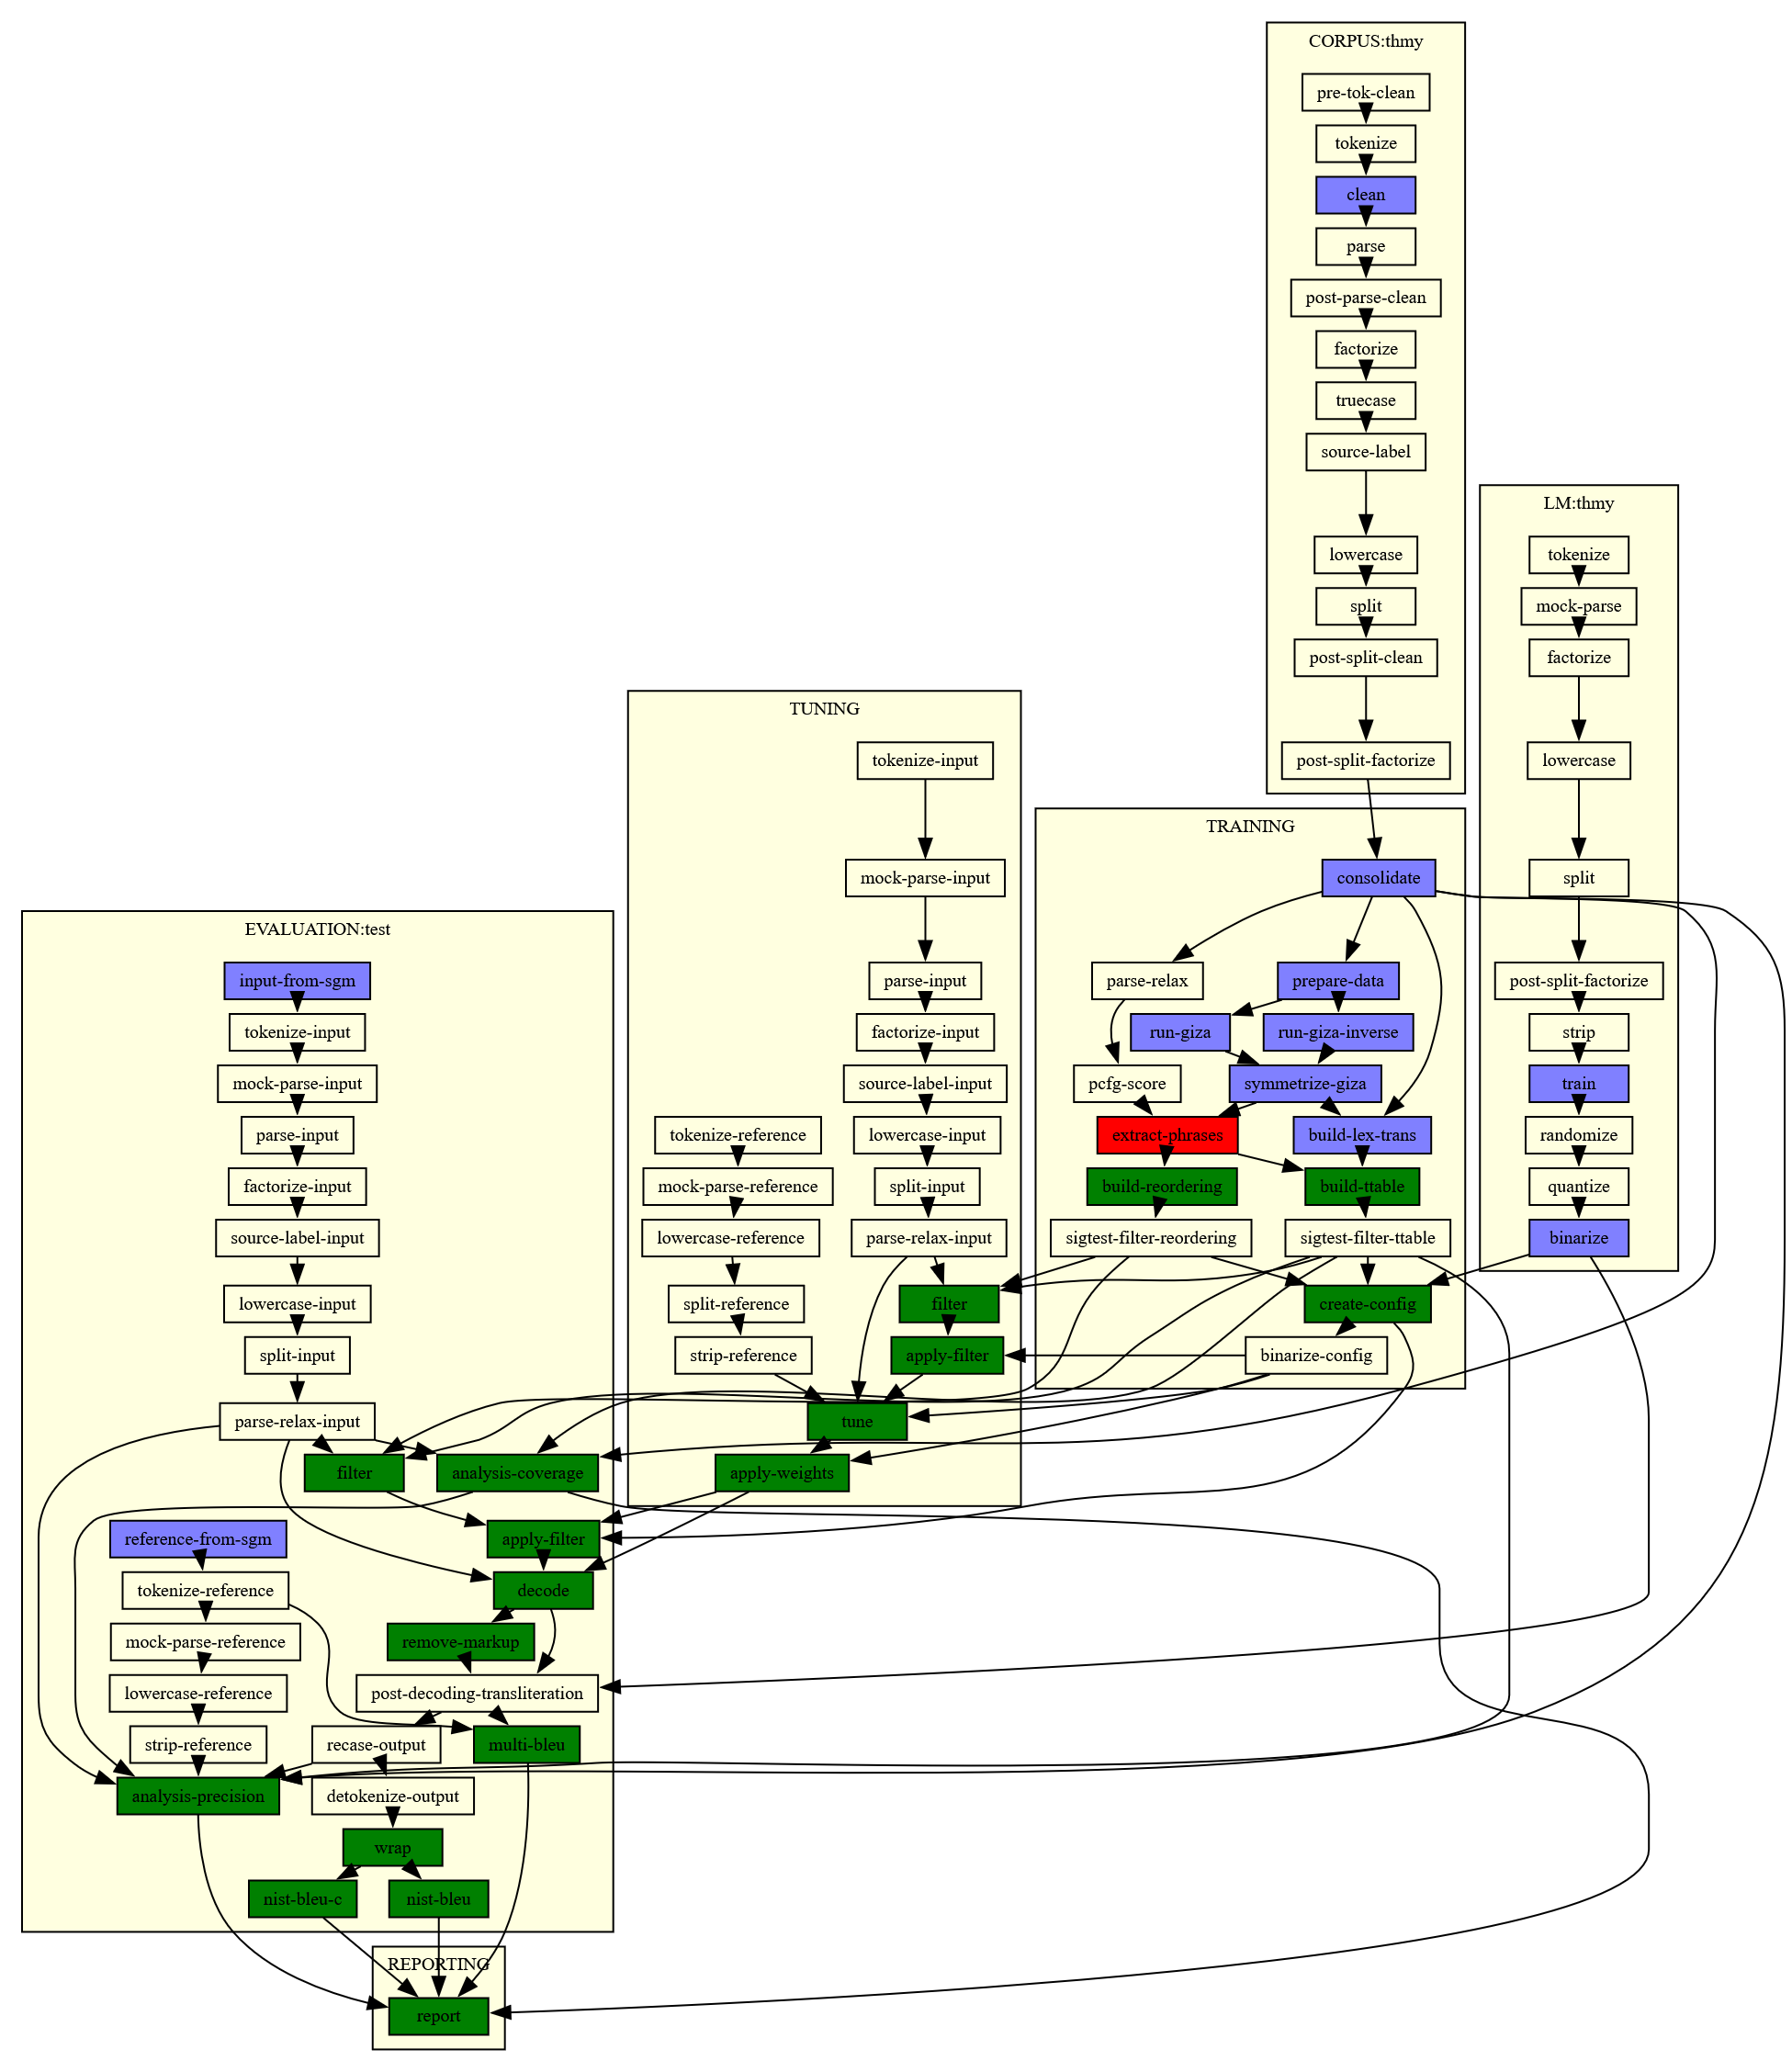

In [61]:
from IPython import display
display.Image("/home/ye/exp/SMT-NMT_tutorial/error-examples/graph.1.myth-big-error1.png", width=800)

အထက်မှာ မြင်ရတဲ့အတိုင်းပဲ မြန်မာ-ထိုင်း အတွက် PBSMT experiment လုပ်ရာမှာ training လုပ်နေတဲ့အပိုင်း၊ အသေးစိတ် ပြောရရင် extract-phrases ဆိုတဲ့ alignment table ကနေ phrase pair တွေကို ဆွဲထုတ်ယူနေတဲ့ နေရာမှာ error ဖြစ်ခဲ့တယ်လို့ ပြနေပါတယ်။ အဲဒါကြောင့် အဲဒီအပိုင်းကို ဆရာတို့ ပြင်မှသာ နောက်အဆင့်တွေဖြစ်တဲ့ tuning တို့ evaluation တို့ဆီကို ဆက်သွားမှာ ဖြစ်ပါတယ်။  

ဒါပေမဲ့ အထက်က run ခဲ့တဲ့ experiment မှာ ထိုင်းကနေမြန်မာ ဘာသာပြန်ဖို့အတွက် မော်ဒယ်ဆောက်တဲ့အပိုင်းမှာတော့ error မပေးတာကို အောက်ပါအတိုင်း တွေ့ရှိရပါတယ်။ ဒီကနေလည်း လေ့လာလို့ ရနိုင်တာက parallel corpus က အတူတူပေမဲ့လည်း ဘာသာပြန်တဲ့ direction ပေါ်ကို မူတည်ပြီးတော့ error မပေးတာကိုလည်း သိရပါလိမ့်မယ်။  

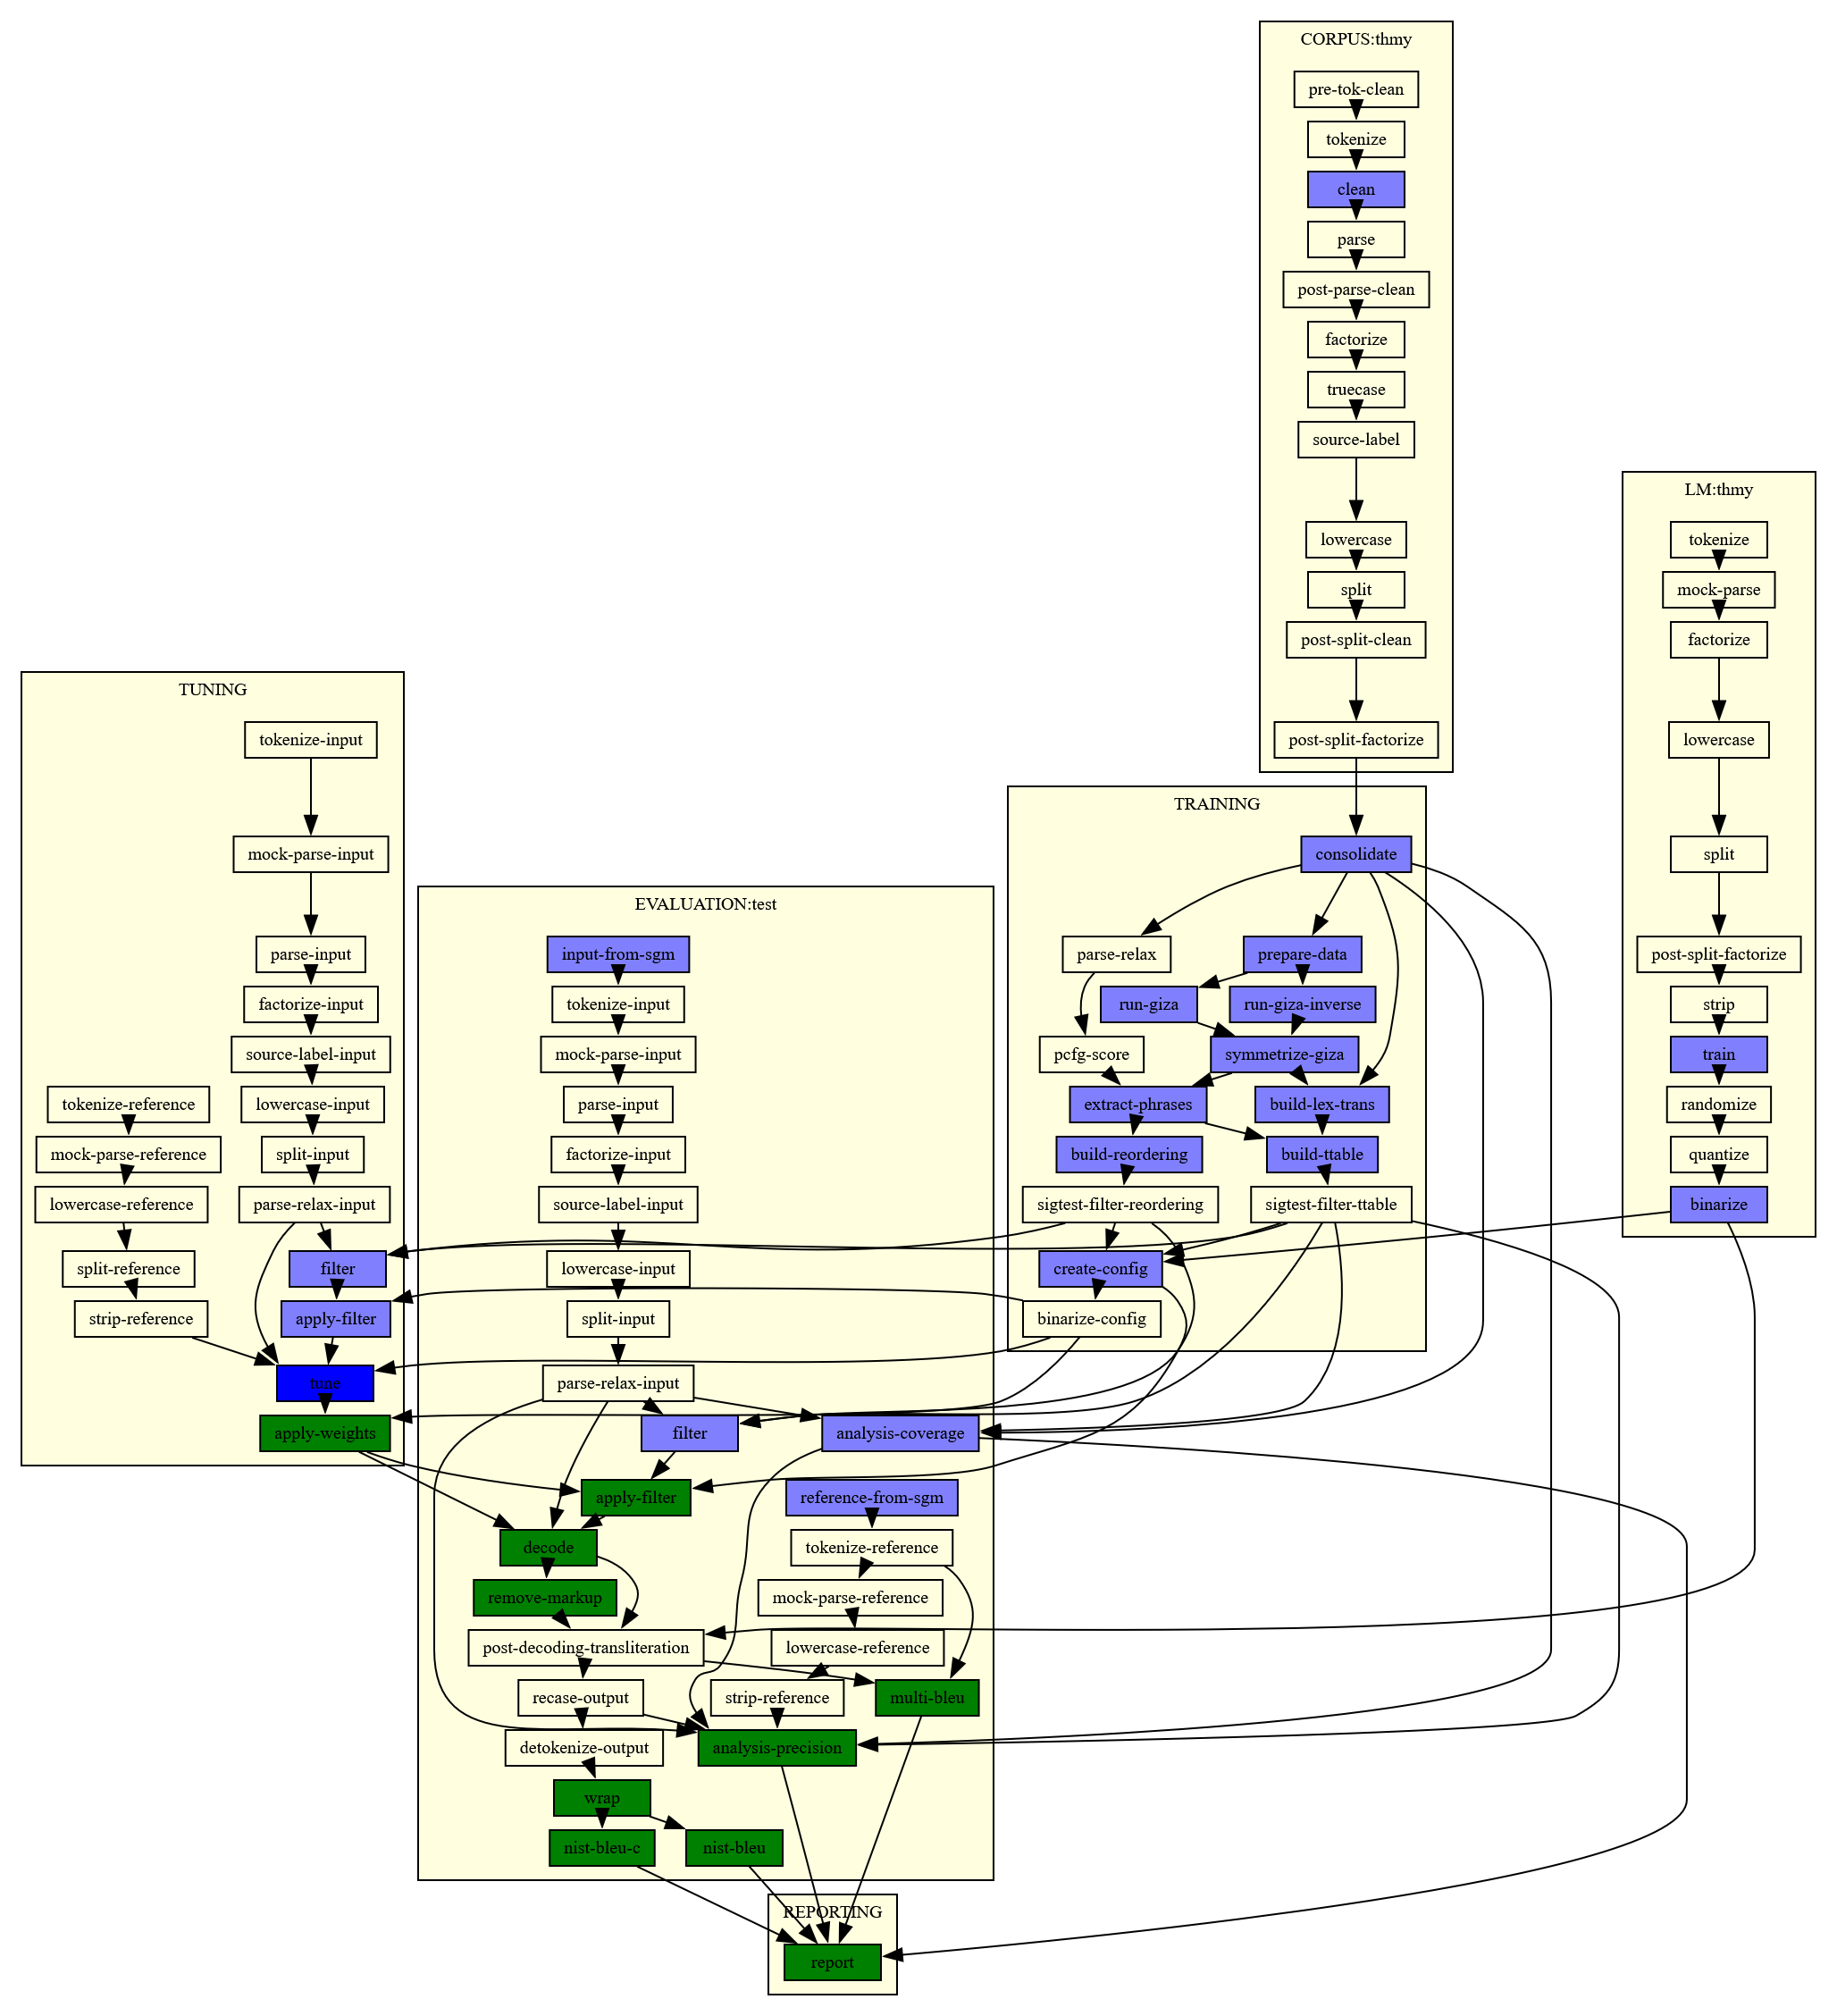

In [63]:
from IPython import display
display.Image("/home/ye/exp/SMT-NMT_tutorial/error-examples/graph.1.thmy-success.png", width=800)

## Error Fixing  

အထက်က error ကို ပြင်ဖို့အတွက်က moses SMT toolkit မှာ perl script က ရှိပြီးသားပါ။ အတန်းထဲမှာလည်း ပြောပြခဲ့သလိုပါပဲ SMT model မဆောက်ခင် မှာ တကယ်တန်းက preprocessing အလုပ်တွေကို လုပ်ဖို့ လိုအပ်တယ်လို့။ အဲဒါကလည်း ကိုယ်သုံးမယ် ဘာသာစကား၊ ပြီးတော့ ဒိုမိန်း၊ ပြီးတော့ ဒေတာက ဘယ်လောက်မသန့်ရှင်းသလဲ စတဲ့အပေါ်ကို မူတည်ပြီး လုပ်ဆောင်ရတာက အမျိုးမျိုးပါပဲ။ ဒီ turorial မှာတော့ model training လုပ်ကြည့်ပြီး ပေးလာတဲ့ special character escaping အဆင့်ကိုပဲ လုပ်ကြည့်ကြရအောင်ပါ။  

moses ကို ဆရာ့ လက်ရှိစက်ထဲမှာက အောက်ပါ path မှာ ထည့်ထားတာမို့ အဲဒီအောက်မှာရှိတဲ့ escape-special-chars.perl ကို ရှာကြည့်ကြရအောင်။  

In [64]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/steps/1'

In [65]:
%cd /home/ye/tool/mosesbin/ubuntu-17.04/moses/

/home/ye/tool/mosesbin/ubuntu-17.04/moses


In [66]:
!ls

bin  scripts


In [67]:
%cd scripts

/home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts


In [68]:
!ls

analysis     generic	    other		server	   training
docker	     Jamfile	    README		share	   Transliteration
ems	     nbest-rescore  recaser		tests
fuzzy-match  OSM	    regression-testing	tokenizer


In [69]:
%cd tokenizer

/home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/tokenizer


In [70]:
!ls *.perl

deescape-special-chars.perl	 pre-tok-clean.perl
deescape-special-chars-PTB.perl  pre-tokenizer.perl
delete-long-words.perl		 remove-non-printing-char.perl
detokenizer.perl		 replace-unicode-punctuation.perl
escape-special-chars.perl	 tokenizer.perl
lowercase.perl			 tokenizer_PTB.perl
normalize-punctuation.perl


**escape-special-chars.perl ကို တွေ့ပါပြီ။**  

In [71]:
!cat ./escape-special-chars.perl

#!/usr/bin/env perl
#
# This file is part of moses.  Its use is licensed under the GNU Lesser General
# Public License version 2.1 or, at your option, any later version.

use warnings;
use strict;

while(<STDIN>) {
  chop;

  # avoid general madness
  s/[\000-\037]//g;
  s/\s+/ /g;
	s/^ //g;
	s/ $//g;

  # special characters in moses
  s/\&/\&amp;/g;   # escape escape
  s/\|/\&#124;/g;  # factor separator
  s/\</\&lt;/g;    # xml
  s/\>/\&gt;/g;    # xml
  s/\'/\&apos;/g;  # xml
  s/\"/\&quot;/g;  # xml
  s/\[/\&#91;/g;   # syntax non-terminal
  s/\]/\&#93;/g;   # syntax non-terminal

  # restore xml instructions
  s/\&lt;(\S+) translation=&quot;(.+?)&quot;&gt; (.+?) &lt;\/(\S+)&gt;/\<$1 translation=\"$2\"> $3 <\/$4>/g;
  print $_."\n";
}


အထက်က perl script က အောက်ပါစာလုံးတွေ၊ သင်္ကေတတွေကို moses ရဲ့ translation engine နဲ့ run တဲ့အခါမှာ error မတက်အောင် ပြောင်းပေးတာပါ။  

- &  →  \&amp;  
- |  →  \&#124; (Very important, as Moses uses "|" for factors)
- <  →  \&lt;  
- \>  →  \&gt;
- '  →  \&apos;
- "  →  \&quot;
- [  →  \&#91;  
- ]  →  \&#93; 

`s/[\000-\037]//g;` ကတော့ non-printable control characters တွေဖြစ်တဲ့ ဥပမာ "Null," "Bell," သို့မဟုတ် "Escape." တို့ကို ဖယ်ပေးတာပါ။  

`s/\s+/ /g;`, `s/^ //g;` နဲ့ `s/ $//g;` တို့ကတော့ space တွေကို ရှင်းပေးတာပါ။  

ဒီ `s/\&lt;(\S+) translation=&quot;(.+?)&quot;&gt; (.+?) &lt;\/(\S+)&gt;/\<$1 translation=\"$2\"> $3 <\/$4>/g;` လိုင်းကတော့ တခါတလေ XML tag အနေနဲ့ မပြောင်းပဲ ထားချင်တာတွေလည်း ရှိတာမို့ အဲဒီအတွက် opening/closing tag တွေကို detect လုပ်ပြီး specific XML markup mode အနေနဲ့ ပြောင်းဖို့ ရေးထားတာပါ။  

ကောင်းပြီ။ ဒီ perl script ကို သုံးပြီး လက်ရှိ error ပေးနေတဲ့ corpus ကို cleaning လုပ်ကြရအောင်။  

In [72]:
%pwd

'/home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/tokenizer'

In [73]:
%cd /home/ye/exp/SMT-NMT_tutorial/clean-data/big/

/home/ye/exp/SMT-NMT_tutorial/clean-data/big


In [74]:
!ls

dev.my	dev.th	test.my  test-sgm  test.th  train.my  train.th


In [75]:
!mkdir escape

In [76]:
!mv *.my ./escape/

In [77]:
!mv *.th ./escape/

In [78]:
%cd ./escape/

/home/ye/exp/SMT-NMT_tutorial/clean-data/big/escape


Shell script တစ်ပုဒ်ကို အောက်ပါအတိုင်း ပြင်ခဲ့တယ်။  

In [79]:
!cat ./run-escape.sh

#!/bin/bash

# Define the path to the Moses tokenizer scripts
SCRIPTS_DIR="/home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts/tokenizer"
ESCAPE_SCRIPT="$SCRIPTS_DIR/escape-special-chars.perl"

# Check if the script exists before running
if [ ! -f "$ESCAPE_SCRIPT" ]; then
    echo "Error: escape-special-chars.perl not found at $ESCAPE_SCRIPT"
    exit 1
fi

echo "Starting character escaping..."

# Loop through all files ending in .my and .th
for file in *.my *.th; do
    # Skip if the file doesn't exist (in case no files match)
    [ -e "$file" ] || continue
    
    echo "Processing: $file"
    
    # Run the escaping script and output to <filename>.escape
    cat "$file" | perl "$ESCAPE_SCRIPT" > "$file.escape"
done

echo "Done! Escaped files have been created with the .escape suffix."


**Executable mode အဖြစ်ပြောင်းမယ်။**  

In [80]:
!chmod +x ./run-escape.sh

**Run မယ်။**

In [81]:
!./run-escape.sh

Starting character escaping...
Processing: dev.my
Processing: test.my
Processing: train.my
Processing: dev.th
Processing: test.th
Processing: train.th
Done! Escaped files have been created with the .escape suffix.


In [82]:
!ls *

dev.my	       dev.th.escape  test.my.escape  train.my	       train.th.escape
dev.my.escape  run-escape.sh  test.th	      train.my.escape
dev.th	       test.my	      test.th.escape  train.th


Escape character တွေအဖြစ် မပြောင်းရသေးခင်က အောက်ပါအတိုင်းပါ။  

In [87]:
!grep -n "<" train.th

149:คุณ เคย เข้า ร่วม การ ประชุม อะไร บ้าง ระหว่าง วัน ที่ < วัน ที่ > ถึง < วัน ที่ > และ ใคร ไป บ้าง
492:ผม ต้องการ คุย เรื่อง ของ การ ตรวจ ของ คุณ < ที่ ตรวจ >
4349:คุณ มี ปฏิทิน หรือ กำหนด การ อื่น ๆ ที่ ใช้ อยู่ หรือ ไม่ หาก คุณ ดู ปฏิทิน ใน โทรศัพท์ คุณ กำลัง ทำ อะไร จาก < วัน ที่ > ถึง < วัน ที่ >
7100:หาก คุณ ดู ผ่าน โทรศัพท์ ใน บาง แอป คุณ เข้า ร่วม กิจกรรม อะไร หรือ พบ ผู้คน ตั้งแต่ < วัน ที่ > ถึง < วัน ที่ >
8159:ก่อนหน้า นี้ เมื่อ เรา พูด ถึง อาการ ของ คุณ คุณ บอก ว่า < อาการ ที่ ผู้ ป่วย ระบุ มา ก่อน > เป็น อาการ แรก ที่ คุณ เกิด จาก COVID - 19
8965:ผม อยาก จะ ยืนยัน หมายเลข ที่ จะ ติดต่อ คุณ คือ < repeat ' best contact number ' โดย ผู้ ป่วย >
9744:เรา มี < ชื่อ ระบบ ตรวจสอบ ใน พื้นที่ > เพื่อ ช่วย ใน การ เช็ค อิน ทุก วัน
10078:ผม ต้องการ คุย เรื่อง ของ การ ตรวจ ของ คุณ < ที่ ตรวจ >
11595:คุณ มี ปฏิทิน หรือ กำหนด การ อื่น ๆ ที่ ใช้ อยู่ หรือ ไม่ หาก คุณ ดู ปฏิทิน ใน โทรศัพท์ คุณ กำลัง ทำ อะไร จาก < วัน ที่ > ถึง < วัน ที่ >
12901:ขอ ตรวจสอบ วัน ที่ ที่ คุณ พบ < อาการ > คร

In [90]:
!grep -n "&lt" train.th.escape

149:คุณ เคย เข้า ร่วม การ ประชุม อะไร บ้าง ระหว่าง วัน ที่ &lt; วัน ที่ &gt; ถึง &lt; วัน ที่ &gt; และ ใคร ไป บ้าง
492:ผม ต้องการ คุย เรื่อง ของ การ ตรวจ ของ คุณ &lt; ที่ ตรวจ &gt;
4349:คุณ มี ปฏิทิน หรือ กำหนด การ อื่น ๆ ที่ ใช้ อยู่ หรือ ไม่ หาก คุณ ดู ปฏิทิน ใน โทรศัพท์ คุณ กำลัง ทำ อะไร จาก &lt; วัน ที่ &gt; ถึง &lt; วัน ที่ &gt;
7100:หาก คุณ ดู ผ่าน โทรศัพท์ ใน บาง แอป คุณ เข้า ร่วม กิจกรรม อะไร หรือ พบ ผู้คน ตั้งแต่ &lt; วัน ที่ &gt; ถึง &lt; วัน ที่ &gt;
8159:ก่อนหน้า นี้ เมื่อ เรา พูด ถึง อาการ ของ คุณ คุณ บอก ว่า &lt; อาการ ที่ ผู้ ป่วย ระบุ มา ก่อน &gt; เป็น อาการ แรก ที่ คุณ เกิด จาก COVID - 19
8965:ผม อยาก จะ ยืนยัน หมายเลข ที่ จะ ติดต่อ คุณ คือ &lt; repeat &apos; best contact number &apos; โดย ผู้ ป่วย &gt;
9744:เรา มี &lt; ชื่อ ระบบ ตรวจสอบ ใน พื้นที่ &gt; เพื่อ ช่วย ใน การ เช็ค อิน ทุก วัน
10078:ผม ต้องการ คุย เรื่อง ของ การ ตรวจ ของ คุณ &lt; ที่ ตรวจ &gt;
11595:คุณ มี ปฏิทิน หรือ กำหนด การ อื่น ๆ ที่ ใช้ อยู่ หรือ ไม่ หาก คุณ ดู ปฏิทิน ใน โทรศัพท์ คุณ กำลัง ทำ อะไร จาก 

## Prepare SGM File for Testset

ဖိုင်တွေအားလုံးကို အသစ်ပြောင်းလိုက်သလို ဖြစ်တာမို့ လက်ရှိ .escape တွေကို ဖြုတ်ပြီး ဒေတာဖိုလ်ဒါထဲကို ပြန်ရွှေ့ရဦးမယ်။ ပြီးတော့ SGM ဖိုင်အဖြစ် ပြောင်းပေးရပါဦးမယ်။  

In [91]:
!cp *.escape ../

In [92]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/clean-data/big/escape'

In [93]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial/clean-data/big


In [94]:
!ls

dev.my.escape  escape	       test-sgm        train.my.escape
dev.th.escape  test.my.escape  test.th.escape  train.th.escape


In [95]:
!mv train.my.escape train.my

In [96]:
!mv train.th.escape train.th

In [97]:
!mv dev.my.escape dev.my

In [98]:
!mv dev.th.escape dev.th

In [99]:
!mv test.my.escape test.my

In [100]:
!mv test.th.escape test.th

In [101]:
!ls *.my *.th

dev.my	dev.th	test.my  test.th  train.my  train.th


In [102]:
!wc *.my *.th

   10000   117871  1127057 dev.my
    8000    93908   896438 test.my
   62625   734667  7029791 train.my
   10000    71013   826135 dev.th
    8000    56113   652038 test.th
   62625   439436  5111625 train.th
  161250  1513008 15643084 total


In [103]:
%cd ./test-sgm

/home/ye/exp/SMT-NMT_tutorial/clean-data/big/test-sgm


In [104]:
!ls

generate_sgms.pl  src2sgm.pl	   test.my.src.sgm  test.th.src.sgm
ref2sgm.pl	  test.my.ref.sgm  test.th.ref.sgm


In [105]:
!rm *.sgm

In [106]:
!ls

generate_sgms.pl  ref2sgm.pl  src2sgm.pl


In [107]:
!perl ./generate_sgms.pl

In [108]:
!ls *.sgm

test.my.ref.sgm  test.my.src.sgm  test.th.ref.sgm  test.th.src.sgm


In [109]:
!wc *.sgm

   8004  109920 1071469 test.my.ref.sgm
   8004  109918 1071443 test.my.src.sgm
   8004   72124  827069 test.th.ref.sgm
   8004   72122  827043 test.th.src.sgm
  32016  364084 3797024 total


In [110]:
!head *.sgm

==> test.my.ref.sgm <==
<refset trglang="my" setid="Thai-Myanmar_data" srclang="any">
<doc sysid="ref" docid="none" genre="8000" origlang="any">
<seg id="1">ခွဲ မှ ရ မှာ လား </seg>
<seg id="2">မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် </seg>
<seg id="3">အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် </seg>
<seg id="4">ဟုတ် ကဲ့ သူ ဖျား ပါ တယ် သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး </seg>
<seg id="5">မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ </seg>
<seg id="6">ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ် </seg>
<seg id="7">မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင် </seg>
<seg id="8">အ ချို ကို လျော့ ချ ကြ ည့် လိုက် ပါ </seg>

==> test.my.src.sgm <==
<srcset setid="Thai-Myanmar_data" srclang="any">
<doc docid="none" genre="8000" origlang="my">
<seg id="1">ခွဲ မှ ရ မှာ လား </seg>
<seg id="2">မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် </seg>
<seg id="3">အ ရက် ကို စွ န့် လွှ

## Train/Tune/Evaluation Again

နောက်တစ်ခေါက် PBSMT experiment ကို ထပ် run ကြည့်ကြမယ်။  
ဒီတစ်ခါတော့ my-th မှာ error မတက်လောက်တော့ဘူးလို့ ယူဆပါတယ်။  

တစ်ခု သတိရလို့။ ဆရာတို့ th-my ရဲ့ BLEU score ကို မကြည့်ရသေးလို့ တချက် ကြည့်ထားလိုက်ကြမယ်။  

In [111]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/clean-data/big/test-sgm'

In [112]:
%cd ../../..

/home/ye/exp/SMT-NMT_tutorial


In [113]:
!ls ./pbsmt-big/baseline/th-my/evaluation/

test.analysis.1		test.filtered.ini.1  test.nist-bleu-c.1
test.cleaned.1		test.input.txt.1     test.output.1
test.detokenized.sgm.1	test.multi-bleu.1    test.output.1.wa
test.filtered.1		test.nist-bleu.1     test.reference.txt.1


မော်ဒယ်ဆောက်တာ၊ tuning လုပ်တာနဲ့ နောက်ဆုံး အကောင်းဆုံး မော်ဒယ်နဲ့ testing လုပ်တာက အဆင်ပြေရင် test.multi-bleu.1 ဆိုတဲ့ ဖိုင်ထဲမှာ BLEU score ရလဒ်တွေကို တွေ့ရလိမ့်မယ်။ အဲဒီဖိုင်ကို ရိုက်ထုတ်ကြည့်ကြရအောင်။  

In [114]:
!cat ./pbsmt-big/baseline/th-my/evaluation/test.multi-bleu.1

BLEU = 32.73, 59.2/38.8/26.8/19.4 (BP=0.989, ratio=0.989, hyp_len=92915, ref_len=93908)


**Training/Tuning/Testing ကို special character တွေကို escape လုပ်ထားပြီးသား ဖိုင်တွေနဲ့ နောက်တစ်ခေါက် လုပ်ကြည့်ကြရအောင်။  

In [115]:
%cd ./pbsmt-big/

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big


In [116]:
!ls

baseline	 generate_configs.pl  run-baseline.pl
config.baseline  run1.log	      steps


In [117]:
!rm -r baseline

In [118]:
!rm run1.log

In [119]:
!ls

config.baseline  generate_configs.pl  run-baseline.pl  steps


ပထမအကြိမ် run ထားတုန်းက ဖိုလ်ဒါနဲ့ log ဖိုင်ကို ရှင်းထားပြီးသွားပြီ။ အရင်ဆုံး config ဖိုင် ထုတ်မယ်။  

In [120]:
!perl ./generate_configs.pl

In [121]:
!ls

baseline  config.baseline  generate_configs.pl	run-baseline.pl  steps


In [122]:
!tree .

.
├── baseline
│   ├── my-th
│   │   └── config.baseline.my-th
│   └── th-my
│       └── config.baseline.th-my
├── config.baseline
├── generate_configs.pl
├── run-baseline.pl
└── steps

5 directories, 5 files


In [ ]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/config.baseline.my-th


**စောင့်နေရင်းနဲ့ လက်ရှိ မြန်မာ-ထိုင်း PBSMT experiment ရဲ့ graph ကို လေ့လာကြည့်တော့ အောက်ပါအတိုင်း tuning လုပ်နေဆဲ ဆိုတာကို တွေ့ရလို့ ပထမအကြိမ် run တုန်းက ဖြစ်တဲ့ error ကိုတော့ special character တွေ escape လုပ်လိုက်ခြင်းအားဖြင့် ဖြေရှင်းလိုက်နိုင်တယ် ဆိုတာ သေချာသွားပါပြီ :)**

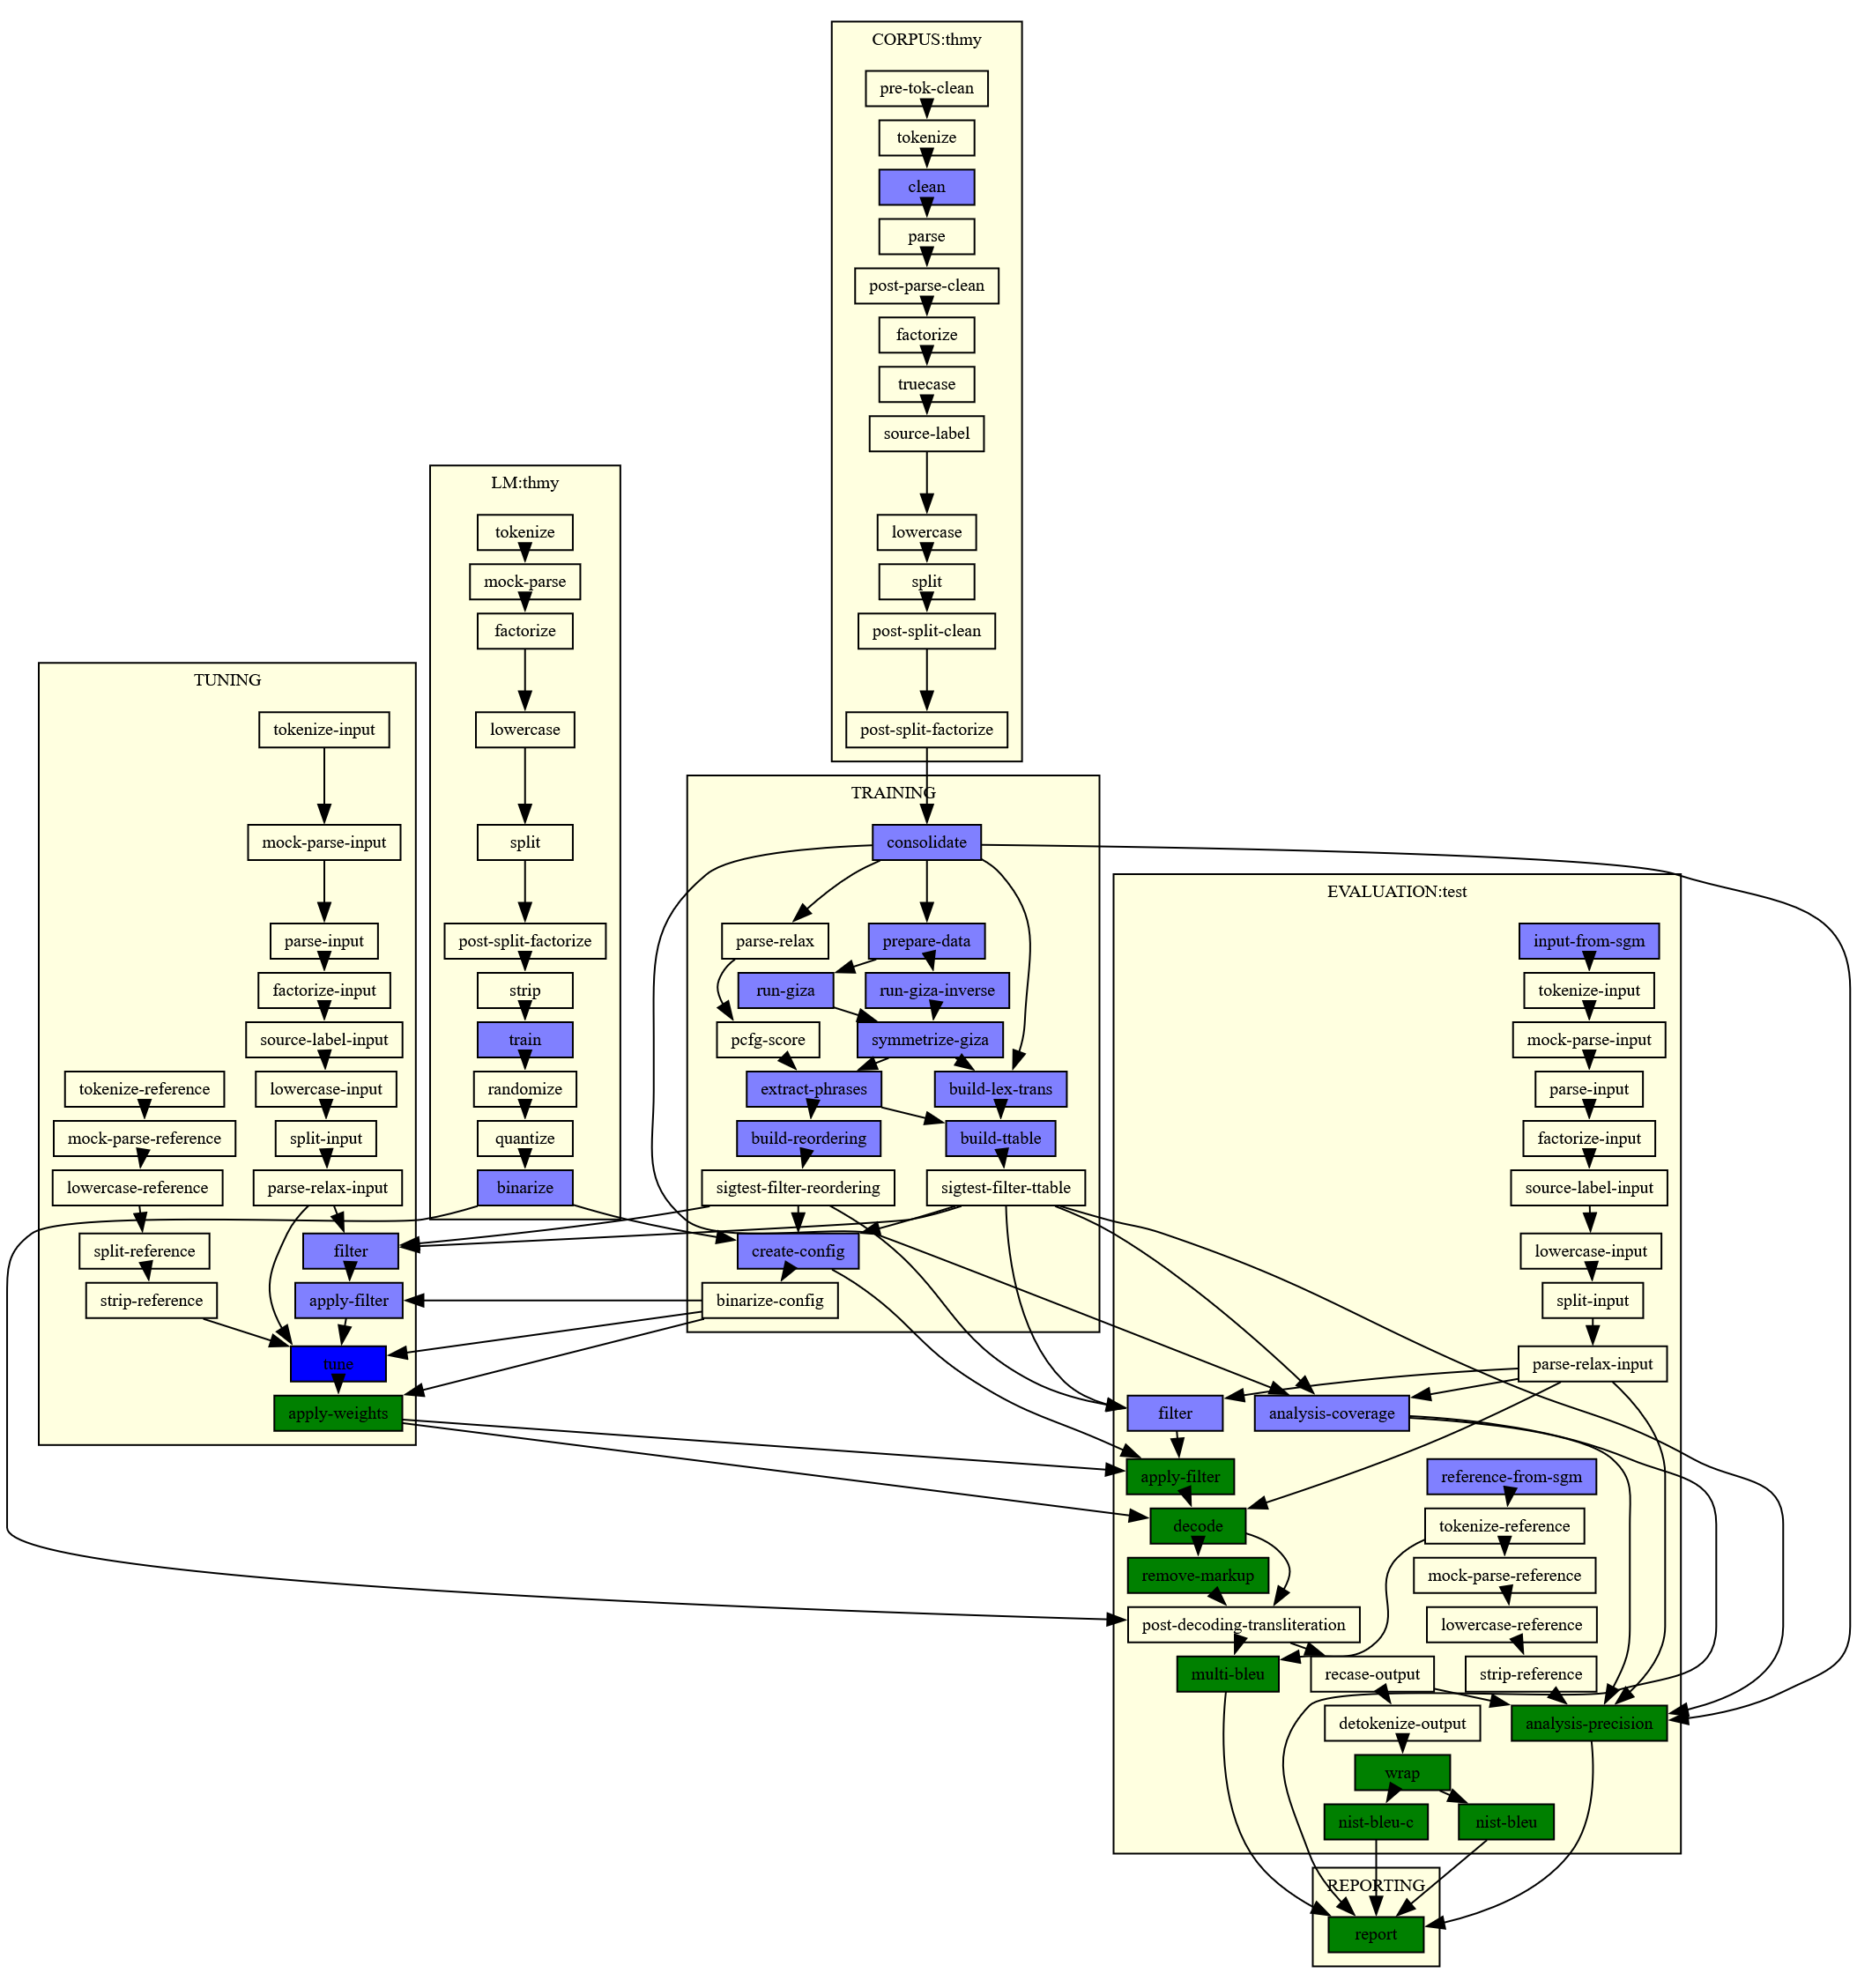

In [127]:
from IPython import display
display.Image("/home/ye/exp/SMT-NMT_tutorial/error-examples/myth-big-tuning.png", width=800)

## Let's See the PBSMT System

Notebook ကို ညဘက် run ထားခဲ့ပြီး မနက်မိုးလင်းမှ ပြန်ကြည့်တယ်။  
Training/Testing/Tuning/Evaluation အကုန် အဆင်ပြေပြေနဲ့ ပြီးမပြီးကို စစ်ဆေးကြည့်ကြရအောင်။   

In [134]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline'

In [135]:
!ls

my-th  th-my


In [136]:
!cd my-th

In [137]:
!tree .

.
├── my-th
│   ├── config.baseline.my-th
│   ├── corpus
│   │   ├── thmy.clean.1.lines-retained
│   │   ├── thmy.clean.1.my
│   │   └── thmy.clean.1.th
│   ├── evaluation
│   │   ├── test.analysis.1
│   │   │   ├── bleu-annotation
│   │   │   ├── corpus-coverage-by-phrase
│   │   │   ├── corpus-coverage-summary
│   │   │   ├── corpus-unknown
│   │   │   ├── input-annotation
│   │   │   ├── n-gram-precision.1
│   │   │   ├── n-gram-precision.2
│   │   │   ├── n-gram-precision.3
│   │   │   ├── n-gram-precision.4
│   │   │   ├── n-gram-recall.1
│   │   │   ├── n-gram-recall.2
│   │   │   ├── n-gram-recall.3
│   │   │   ├── n-gram-recall.4
│   │   │   ├── precision-by-corpus-coverage
│   │   │   ├── precision-by-input-word
│   │   │   ├── precision-by-ttable-coverage
│   │   │   ├── segmentation
│   │   │   ├── segmentation-annotation
│   │   │   ├── summary
│   │   │   ├── ttable-coverage-by-phrase
│   │   │   ├── ttable-coverage-summary
│   │   │   └── ttable-unknown
│   │   ├── test.c

**Alignment Table ကို ဝင်ကြည့်ရအောင်**

In [152]:
%cd my-th/training

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training


In [153]:
!ls -F --color=auto

corpus.1.my@  corpus.1.th@  giza.1/  giza-inverse.1/  prepared.1/


In [154]:
%cd giza.1

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/giza.1


In [157]:
!ls -F

th-my.A3.final.gz  th-my.cooc  th-my.gizacfg  tmp/


**.gz ဖိုင် မို့လို့ temporary folder တစ်ခုဆောက်ပြီး အဲဒီထဲမှာပဲ ဖြေပြီး ဖွင့်ကြည့်ကြရအောင်**

In [156]:
!mkdir tmp

In [168]:
%cd tmp

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/giza.1/tmp


In [ ]:
!cp ../th-my.A3.final.gz .

**gunzip command နဲ့ ပုံမှန် text ဖိုင်ဖြစ်အောင် ဖြေလိုက်တယ်**

In [171]:
!gunzip ./th-my.A3.final.gz

In [172]:
!ls

th-my.A3.final


In [175]:
!head -n 50 ./th-my.A3.final

# Sentence pair (1) source length 10 target length 10 alignment score : 2.24352e-26
คือ มี อาการ อย่าง ใด อย่าง หนึ่ง ต่อ ไป นี้ 
NULL ({ 9 }) အောက် ({ 7 8 10 }) ပါ ({ }) ရော ({ }) ဂါ ({ }) လက္ခ ({ 1 4 5 6 }) ဏာ ({ 3 }) တွေ ({ }) များ ({ }) ရှိ ({ 2 }) ရင် ({ }) 
# Sentence pair (2) source length 8 target length 5 alignment score : 1.08954e-11
ใจเย็น ๆ ก่อน นะ คะ 
NULL ({ }) စိတ် ({ }) ကို ({ }) အေး ({ 1 }) အေး ({ 2 }) ဆေး ({ }) ဆေး ({ }) ထား ({ 3 }) ပါ ({ 4 5 }) 
# Sentence pair (3) source length 12 target length 5 alignment score : 3.80172e-09
ไม่ มี โรค ประจำ ตัว 
NULL ({ }) နာ ({ }) တာ ({ }) ရှည် ({ }) ရော ({ }) ဂါ ({ 3 4 5 }) ရယ် ({ }) လို့ ({ }) မ ({ 1 }) ရှိ ({ 2 }) ပါ ({ }) ဘူး ({ }) ဗျ ({ }) 
# Sentence pair (4) source length 4 target length 3 alignment score : 1.53981e-08
อาการ เบื้อง ต้น 
NULL ({ }) လက္ခ ({ }) ဏာ ({ 1 2 3 }) တွေ ({ }) နဲ့ ({ }) 
# Sentence pair (5) source length 18 target length 14 alignment score : 2.38628e-34
แล้ว เอา หู ฟัง วาง ตรงเหนือ ข้อ พับ ตรง นี้ นิ

- The NULL token handles words that don't translate to anything.
- The numbers in ({ }) represent the position of the source word that aligns to that target word.

In [3]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/giza.1


In [4]:
!ls

th-my.A3.final.gz  th-my.cooc  th-my.gizacfg  tmp


In [5]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training


In [7]:
!ls --color=auto

corpus.1.my  corpus.1.th  giza.1  giza-inverse.1  prepared.1


ဒီတစ်ခါတော့ inverse alignment ဖိုင်ကို လေ့လာကြည့်ရအောင်။  

In [10]:
%cd ./giza-inverse.1/

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/giza-inverse.1


In [11]:
!ls --color=auto

my-th.A3.final.gz  my-th.cooc  my-th.gizacfg


In [12]:
!mkdir tmp

In [13]:
!cp my-th.A3.final.gz ./tmp/

In [14]:
%cd ./tmp/

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/training/giza-inverse.1/tmp


In [15]:
!gunzip ./my-th.A3.final.gz

In [16]:
!ls --color=auto

my-th.A3.final


In [17]:
!head -n 50 ./my-th.A3.final

# Sentence pair (1) source length 10 target length 10 alignment score : 2.16558e-24
အောက် ပါ ရော ဂါ လက္ခ ဏာ တွေ များ ရှိ ရင် 
NULL ({ }) คือ ({ }) มี ({ 2 9 }) อาการ ({ 3 4 5 6 7 8 }) อย่าง ({ }) ใด ({ 1 10 }) อย่าง ({ }) หนึ่ง ({ }) ต่อ ({ }) ไป ({ }) นี้ ({ }) 
# Sentence pair (2) source length 5 target length 8 alignment score : 5.24945e-14
စိတ် ကို အေး အေး ဆေး ဆေး ထား ပါ 
NULL ({ }) ใจเย็น ({ 1 2 3 4 5 6 7 }) ๆ ({ }) ก่อน ({ }) นะ ({ 8 }) คะ ({ }) 
# Sentence pair (3) source length 5 target length 12 alignment score : 5.83236e-31
နာ တာ ရှည် ရော ဂါ ရယ် လို့ မ ရှိ ပါ ဘူး ဗျ 
NULL ({ }) ไม่ ({ 8 11 }) มี ({ 7 9 10 }) โรค ({ 4 5 }) ประจำ ({ 3 6 12 }) ตัว ({ 1 2 }) 
# Sentence pair (4) source length 3 target length 4 alignment score : 1.54375e-08
လက္ခ ဏာ တွေ နဲ့ 
NULL ({ }) อาการ ({ 1 2 3 4 }) เบื้อง ({ }) ต้น ({ }) 
# Sentence pair (5) source length 14 target length 18 alignment score : 6.26777e-38
ပြီး တဲ့ အ ခါ နား ကြပ် ကို တံ တော င့် ဆစ် နား မှာ ထား မှာ မို့ ပါ ရှင် 
NULL ({ 3 }) แล้

## For Your Information

အထက်မှာ ကြည့်နေတဲ့ ဖိုင်တွေက IBM Models (1-5) နဲ့ HMM training ရဲ့ alignment ဖိုင်တွေပါပဲ။ GIZA++ က အခြေခံအားဖြင့် asymmetric နည်းလမ်းပါ။ အဲဒါကြောင့် သူက multiple source words ကနေ single word ကိုပဲ mapping လုပ်နိုင်ပြီး အသွားအပြန် မလုပ်ပေးနိုင်ဘူး။ အဲဒါကြောင့် လက်တွေ့ alignment လုပ်တဲ့အခါမှာ ပထမဆုံး source ကနေ target ကို alignment အရင်လုပ်တယ်။ ပြီးတော့ target ကနေ source ကိုလည်း alignment လုပ်တယ်။ အဲဒီ alignment နှစ်ခုကနေမှ ပြန်ပေါင်းယူတဲ့ ပုံစံပါ။  

### The prepared.1 Folder: The "Setup"  

Vocab ဆောက်တာကို အရင်ဆုံးလုပ်ပါတယ်။ စာလုံးတွေကို integer အဖြစ် mapping လုပ်တဲ့အပိုင်းပါ။  

|File|Purpose|
|---|---|
|th.vcb / my.vcb|	Vocabulary files. Maps every unique word in Thai and Myanmar to a unique integer ID. GIZA++ doesn't process strings; it processes these IDs.|
|th-my-int-train.snt|	Integerized sentences. This is your parallel corpus where every word has been replaced by its ID from the .vcb files.|
|.vcb.classes|	Word Classes. Generated by a tool called mkcls. It groups words into clusters (e.g., "days of the week" might be in one cluster) to help the alignment model generalize better, especially for IBM Model 4.|

### 2. `giza.1` and `giza-inverse.1`: The "Learning"  

အထက်မှာ ပြောခဲ့တဲ့အတိုင်းပဲ GIZA++ က "many-to-one" alignment နှစ်ခါ ပြီးသွားတဲ့အခါမှာတော့ အောက်ပါဖိုင်နှစ်ဖိုင်ကို ရလာပါလိမ်မယ်။  

- giza.1 (Forward): Usually Thai $\rightarrow$ Myanmar.
- giza-inverse.1 (Backward): Myanmar $\rightarrow$ Thai.

အထက်က နှစ်ဖိုင်ကနေမှ ပြန်ပေါင်းယူထားတဲ့ alignment ဖိုင်က အောက်ပါအတိုင်းပါ။ ဒါက မြန်မာ-ထိုင်း အတွဲအတွက် နောက်ဆုံး alignment ရလဒ်ဖိုင်ပါပဲ။   

- th-my.A3.final.gz


တကယ်တမ်း အသေးစိတ် ဘယ်လို လုပ်သလဲ ဆိုတာကတော့ အောက်ပါအတိုင်းပါပဲ။    

## The Workflow

The process follows a very specific sequence of scripts (usually managed by the Moses `train-model.perl` script):

1. Word Clustering (`mkcl`s): It runs on both languages to create the `.classes` files. This helps the model handle rare words by looking at the behavior of their "class."
2. Vocabulary Extraction: It scans your corpus to create the `.vcb` maps.
3. Sentence Integerization: It converts your raw text into `.snt` files.
4. GIZA++ Training:
   - It starts with **IBM Model 1** (lexical translation probabilities, no word order).
   - It moves to **HMM** (captures local word order).
   - It finishes with **IBM Model 4** (handles "fertility"—the idea that one word can produce two words).
   - The .A3.final is the output of the very last iteration of the highest model used.

Debugging အတွက်က လိုအပ်တဲ့အခါမှာ `.gizacfg` ဖိုင်တွေကို ဝင်ကြည့်ပါ။   

## Phrase Table

ဆက်လက်ပြီး phrase table ကို လေ့လာရအောင်။  
model ဖိုလ်ဒါအောက်ကို directory change ပါမယ်။  

In [18]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model


In [19]:
!ls --color=auto

aligned.1.grow-diag-final-and  lex.1.f2e
extract.1.inv.sorted.gz        moses.ini.1
extract.1.o.sorted.gz          phrase-table.1.gz
extract.1.sorted.gz            reordering-table.1.wbe-msd-bidirectional-fe.gz
lex.1.e2f


ပြောရရင် မော်ဒယ် ဖိုလ်ဒါက PBSMT ရဲ့ translation အတွက် အဓိကသုံးတဲ့ အသိဉာဏ်ပိုင်းလို့ ပြောလို့ ရပါတယ်။ GIZA++ က word-level alignment ပဲ အကြမ်းလုပ်ပေးတာပါ။ ဒီ model ဖိုလ်ဒါအထဲမှာတော့ phrase-level mapping နဲ့ probability score တွေ ရအောင်တွက်ထုတ်ထားတဲ့ ဖိုင်တွေပါဝင်လာပါပြီ။ အဲဒီ phrase pair, probability score တွေကိုပဲ သုံးပြီးတော့ moses decoder က ဘာသာပြန်တဲ့အလုပ်ကို လုပ်ပေးသွားမှာပါ။ ဖိုင်တစ်ဖိုင်ချင်းစီ ကိုရှင်းပြထားတဲ့ အောက်ပါ ဇယားကို လေ့လာပါ။  

|File|Description|
|---|---|
|`aligned.1.grow-diag-final-and`|	The symmetrized word alignment file. It combines the giza.1 and giza-inverse.1 outputs using the grow-diag-final-and heuristic to create a many-to-many alignment grid.
|`lex.1.e2f` / `lex.1.f2e`|	Lexical translation tables. These contain word-level translation probabilities|
|`extract.1.sorted.gz`|	An intermediate file containing all extracted phrase pairs that are "consistent" with the word alignment, sorted for efficient scoring.|
|`extract.1.inv.sorted.gz`|	The inverse version of the extract file, used to calculate the "backward" translation probabilities|
|`extract.1.o.sorted.gz`|	Contains orientation information for every phrase pair (monotonic, swapped, or discontinuous), used to build the reordering table.|
|`phrase-table.1.gz`|	The core model. It lists every source phrase, its possible target translations, and 5 scores (usually: inverse phrase prob, lexical weight, direct phrase prob, inverse lexical weight, and a phrase penalty).|
|`reordering-table.1..gz`|	The Lexicalized Reordering Model. This tells Moses how likely a phrase is to change its position relative to the previous phrase (e.g., in Thai-Myanmar, how likely is an adjective-noun swap?).|
|`moses.ini.1`|	The Configuration file. This is the "map" for the decoder. It tells Moses which phrase table to load, which reordering model to use, and what weights to apply to each feature.|

In [20]:
%mkdir tmp

In [21]:
!cp phrase-table.1.gz ./tmp/

In [23]:
!cp reordering-table.1.wbe-msd-bidirectional-fe.gz ./tmp/

In [24]:
%cd tmp

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/tmp


In [25]:
!gunzip ./phrase-table.1.gz

In [26]:
!ls --color=auto

phrase-table.1  reordering-table.1.wbe-msd-bidirectional-fe.gz


In [28]:
!head -n 300 ./phrase-table.1

! ! ! ||| !!! ||| 0.331844 0.041477 0.331844 0.75 ||| 0-0 1-0 2-0 ||| 1 1 1 ||| |||
% ||| % ||| 0.306122 0.328767 0.833333 0.657534 ||| 0-0 ||| 49 18 15 ||| |||
% ||| % ถือ ||| 0.653084 0.179768 0.108847 0.0360293 ||| 0-0 0-1 ||| 3 18 3 ||| |||
% က ||| ส่วน ||| 0.000932147 1.09161e-06 0.331844 0.0073358 ||| 1-0 ||| 356 1 1 ||| |||
% က နည်း သည် ||| เปอร์เซ็นต์ ||| 0.0474063 0.000164062 0.331844 0.0260911 ||| 0-0 1-0 2-0 3-0 ||| 7 1 1 ||| |||
% ဆို ||| % ||| 0.00677233 0.00272104 0.165922 0.657534 ||| 0-0 ||| 49 2 1 ||| |||
% ဆို ||| % ถือ ว่า ||| 0.0829611 0.0114478 0.165922 0.00245314 ||| 0-0 0-1 1-2 ||| 4 2 1 ||| |||
% ဆို တော့ ||| % ถือ ว่า ||| 0.489813 0.000154099 0.489813 0.000819808 ||| 0-0 1-0 2-0 0-1 1-2 ||| 4 4 3 ||| |||
% ဆို တော့ ||| % ถือ ว่า รุนแรง ||| 0.331844 0.000477638 0.0829611 4.65487e-07 ||| 0-0 1-0 2-0 0-1 1-2 ||| 1 4 1 ||| |||
% ဆို တော့ ပြင်း ထန် ||| % ถือ ว่า รุนแรง มาก ||| 0.576972 4.33677e-06 0.576972 2.94149e-05 ||| 0-0 0-1 1-2 2-2 3-3 4-3 3-4 ||| 2 2 2 ||| ||

## Reordering Table 

ဒီတခါတော့ reordering table ကို လေ့လာကြည့်ရအောင်။  

In [29]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/tmp'

In [30]:
!gunzip ./reordering-table.1.wbe-msd-bidirectional-fe.gz

In [31]:
!head -n 300 ./reordering-table.1.wbe-msd-bidirectional-fe

! ! ! ||| !!! ||| 0.6 0.2 0.2 0.6 0.2 0.2
% ||| % ||| 0.69697 0.030303 0.272727 0.030303 0.030303 0.939394
% ||| % ถือ ||| 0.777778 0.111111 0.111111 0.777778 0.111111 0.111111
% က ||| ส่วน ||| 0.2 0.2 0.6 0.2 0.2 0.6
% က နည်း သည် ||| เปอร์เซ็นต์ ||| 0.6 0.2 0.2 0.6 0.2 0.2
% ဆို ||| % ||| 0.6 0.2 0.2 0.2 0.2 0.6
% ဆို ||| % ถือ ว่า ||| 0.6 0.2 0.2 0.2 0.2 0.6
% ဆို တော့ ||| % ถือ ว่า ||| 0.777778 0.111111 0.111111 0.555556 0.111111 0.333333
% ဆို တော့ ||| % ถือ ว่า รุนแรง ||| 0.6 0.2 0.2 0.2 0.2 0.6
% ဆို တော့ ပြင်း ထန် ||| % ถือ ว่า รุนแรง มาก ||| 0.714286 0.142857 0.142857 0.714286 0.142857 0.142857
% ဆို ရင် ||| % ||| 0.6 0.2 0.2 0.2 0.2 0.6
% ဆို ရင် အ ||| % ||| 0.6 0.2 0.2 0.2 0.2 0.6
% ဆို ရင် အ ဆ ||| % ||| 0.6 0.2 0.2 0.2 0.2 0.6
% တော့ ||| % ||| 0.714286 0.142857 0.142857 0.142857 0.142857 0.714286
% နည်း ||| เปอร์เซ็นต์ ||| 0.6 0.2 0.2 0.2 0.2 0.6
% နည်း နေ ||| เปอร์เซ็นต์ ||| 0.6 0.2 0.2 0.2 0.2 0.6
% နည်း နေ သည် ||| เปอร์เซ็นต์ ||| 0.6 0.2 0.2 0.6 0.2 0.2
% နည်း လာ သည် ||| 

## moses.ini  

Training လုပ်ပြီးထွက်လာတဲ့ moses.ini ဖိုင်ကိုလေ့လာကြည့်ရအောင်။  

In [32]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model


In [33]:
!ls --color=auto

aligned.1.grow-diag-final-and  lex.1.f2e
extract.1.inv.sorted.gz        moses.ini.1
extract.1.o.sorted.gz          phrase-table.1.gz
extract.1.sorted.gz            reordering-table.1.wbe-msd-bidirectional-fe.gz
lex.1.e2f                      tmp


In [34]:
!cat moses.ini.1

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/phrase-table.1 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/reordering-table.1.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/lm/thmy.binlm.1 order=5

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You MUST tune the weights.
# Documentation for tuning is here: http://www.statmt.org/moses/?n=FactoredTraining.Tun

============

moses.ini ဖိုင်က moses decoder အတွက် blueprint ပါပဲ။ ဒီဖိုင်ထဲကနေ decoder က ဘယ် path အောက်မှာရှိတဲ့ မော်ဒယ်ကို load လုပ်ယူရမယ်။ အကောင်းဆုံး translation ရလဒ် ရလာနိုင်ဖို့အတွက် ဘယ်မော်ဒယ်တွေကို (i.e. language model, phrase table etc.) ဘယ်လို အလေးပေး (i.e. weight values) ပြီးတွက်ရမယ်ဆိုတာကို ညွှန်ကြားထားတာပါ။ Training လုပ်ပြီးသွားတဲ့အချိန်မှာ training data pair တွေကနေ သူလေ့လာထားသလောက် weight တွေကို သတ်မှတ်ပေးထားတာပါ။ 

### 1. Structural Settings

[input-factors]
- `0`: This indicates a single-factor model (usually just the surface word form). In factored models, you might see 0,1,2 representing words, POS tags, and lemmas.

[mapping]
- `0 T 0`: This defines the decoding steps. T 0 means "apply Translation Model 0." If you had a generation model (e.g., to create a lemma from a word), it would be listed here.

[distortion-limit]
- `6`: This controls reordering. It limits how far a source phrase can "jump" to find its target translation. A limit of 6 means the decoder can move 6 positions away from the current word. For language pairs with very different structures (like Myanmar and English), this is sometimes increased.

### 2. Feature Functions 

This section lists the "ingredients" of the log-linear translation model.  

|Feature|	Description|
|---|---|
|`UnknownWordPenalty`|	Penalizes the model for every word it cannot translate (OOV).|
|`WordPenalty`|	Controls the length of the translation. Negative weights encourage longer sentences; positive weights encourage shorter ones.|
|`PhrasePenalty`|	Controls the number of phrases used. It balances between using many short phrases versus a few long phrases.|
|`PhraseDictionaryMemory`|	Loads the Phrase Table into RAM. num-features=4 refers to the four probabilities we discussed earlier (inverse/direct phrase and lexical weights).|
|`LexicalReordering`|	Loads the reordering table. wbe-msd-bidirectional-fe-allff indicates it uses word-based extraction and tracks swaps in both directions.|
|`Distortion`|	A basic reordering feature based on the distance words move.|
|`KENLM`|	The Language Model (LM). Your order=5 means it checks sequences of up to 5 words to ensure the Thai output sounds natural.|

### 3. Weights ([weight])

The weights determine the "influence" of each feature. In SMT, the final score for a translation is the weighted sum of all features:

$$Score = \sum_{i} w_i \cdot f_i(x, y)$$

- `TranslationModel0= 0.2 0.2 0.2 0.2`: These are the weights for the four scores in your phrase table.
- `LexicalReordering0= 0.3 0.3 0.3 0.3 0.3 0.3`: These are the weights for the six reordering scores (Monotonic/Swap/Discontinuous for both directions).
- `LM0= 0.5`: Notice the Language Model often has a high weight. This is because the LM is the primary judge of whether the output is grammatically correct.


## moses.ini (After Tuning)

အတန်းထဲမှာ ရှင်းပြခဲ့တဲ့အတိုင်းပါပဲ။ Tuning step ပြီးသွားတဲ့အခါမှာတော့ moses.ini ဖိုင်ရဲ့ တချို့ weight value တွေက အသေးစိတ်သတ်မှတ်လာတာကို အောက်ပါအတိုင်း တွေ့ရပါလိမ့်မယ်။  

In [35]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/tuning

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/tuning


In [36]:
!ls --color=auto

filtered.1  moses.filtered.ini.1  moses.ini.1  moses.tuned.ini.1  tmp.1


Tuning သို့မဟုတ် optimization အဆင့်ကတော့ PBSMT, HPBSMT, OSM နည်းလမ်းတွေနဲ့ မော်ဒယ်ဆောက်တဲ့အခါမှာ အကြာဆုံး အပိုင်းဖြစ်ပါတယ်။ ဘာကြောင့်လဲ ဆိုတော့ moses က ဖြစ်နိုင်ခြေ phrase အတွဲတွေနဲ့ တခြား မော်ဒယ်တွေနဲ့ ပေါင်းစပ်မှုတွေလုပ်ပြီး development data ထဲက စာကြောင်းတစ်ကြောင်းချင်းစီအတွက် အကောင်းဆုံး ဘာသာပြန်ပေးနိုင်ခြေ (i.e. best weight တန်ဖိုး) တွေကို ရှာဖွေတာမို့လို့ပါ။ အဆင်ပြေပြေနဲ့ ဘာ error မှမပေးပဲ ပြီးသွားရင်တော့ အထက်မှာ မြင်ရတဲ့အတိုင်း moses.ini ဖိုင်အသစ်နှစ်မျိုး (i.e. filtered, tuned) ထပ်ထွက်လာပါလိမ့်မယ်။ အဲဒါကြောင့် စုစုပေါင်း ini ဖိုင် သုံးမျိုး ရလာပါလိမ့်မယ်။ အသေးစိတ်က အောက်ပါ ဇယားမှာ ရှင်းပြထားသလိုပါပဲ။  

### 1. The Three .ini Files 

|File|What it is|
|---|---|
|`moses.ini.1`| **The Original.** This is a copy of your untuned configuration from the `model` folder. It uses default weights and points to your full, massive phrase table.|
|`moses.filtered.ini.1`| **The MERT Engine.** This is the config Moses uses during the tuning process. It points to the **filtered** tables in the `filtered.1` folder. This makes tuning run much faster because it doesn't have to search the entire phrase table-only the parts relevant to your tuning set.|
|`moses.tuned.ini.1`| **The Winner.** This is your **final product**. It contains the optimized weights (e.g., `TranslationModel0= 0.12 0.05 0.21...`). You should use this file for your final translation/testing.|

filtered.ini ဖိုင်ကို လေ့လာကြည့်ရအောင်။  

In [37]:
!cat moses.filtered.ini.1

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/tuning/filtered.1/phrase-table.0-0.1.1.gz input-factor=0 output-factor=0 
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/tuning/filtered.1/reordering-table.1.wbe-msd-bidirectional-fe.0-0.1 
Distortion
KENLM name=LM0 factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/lm/thmy.binlm.1 order=5

# dense weights for feature functions
[weight]
# The default weights are NOT optimized for translation quality. You MUST tune the weights.
# Documentation for tuning is here: http://www.st

Tuning လုပ်ပြီးတော့ ရလာတဲ့ final ini ဖိုင်ကို လေ့လာကြည့်ရအောင်။  
ဒီမို ဘာညာလုပ်ဖို့ အသုံးပြုတဲ့အခါမှာလည်း ဒီ moses.tuned.ini.1 ကိုပဲ သုံးကြတာပါ။  

In [38]:
!cat moses.tuned.ini.1

#########################
### MOSES CONFIG FILE ###
#########################

# input factors
[input-factors]
0

# mapping steps
[mapping]
0 T 0

[distortion-limit]
6

# feature functions
[feature]
UnknownWordPenalty
WordPenalty
PhrasePenalty
PhraseDictionaryMemory name=TranslationModel0 num-features=4 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/phrase-table.1 input-factor=0 output-factor=0
LexicalReordering name=LexicalReordering0 num-features=6 type=wbe-msd-bidirectional-fe-allff input-factor=0 output-factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/model/reordering-table.1.wbe-msd-bidirectional-fe.gz
Distortion
KENLM name=LM0 factor=0 path=/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/lm/thmy.binlm.1 order=5

# core weights
[weight]
LexicalReordering0= 0.0461365 0.0337038 0.0660466 0.0478805 0.00992487 0.126209
Distortion0= 0.0200328
LM0= 0.260847
WordPenalty0= 0.0706379
PhrasePenalty0= -0.0961515
TranslationModel0= 0.0973455 0.060

## BLEU Scores

ခုလောက်ဆိုရင်တော့ PBSMT နဲ့ ပတ်သက်ပြီးအတွင်းပိုင်းကို တော်တော်လေး သိသွားပြီလို့ ယုံကြည်ပါတယ်။  
နောက်ဆုံးအနေနဲ့ translation performance ကို BLEU score နဲ့ အကဲဖြတ်ကြရအောင်။  

ပထမဆုံး မြန်မာကနေ ထိုင်းကို ဘာသာပြန်တာကို test data စာကြောင်းရေ ရှစ်ထောင်နဲ့ BLEU score ဘယ်လောက် ရသလဲ ဆိုတာ ရှာဖွေကြည့်ရအောင်။  

In [39]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/evaluation

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/my-th/evaluation


In [40]:
!ls

test.analysis.1		test.filtered.ini.1  test.nist-bleu-c.1
test.cleaned.1		test.input.txt.1     test.output.1
test.detokenized.sgm.1	test.multi-bleu.1    test.output.1.wa
test.filtered.1		test.nist-bleu.1     test.reference.txt.1


In [41]:
!cat test.multi-bleu.1

BLEU = 36.80, 57.3/39.7/31.1/25.9 (BP=1.000, ratio=1.004, hyp_len=56314, ref_len=56113)


အထက်မှာ မြင်ရတဲ့အတိုင်း 36.80 ရပါတယ်။  

ထိုင်းကနေ မြန်မာဘက် ကို ဘာသာပြန်တဲ့ ရလဒ်ကိုလည်း လေ့လာကြည့်ရအောင်။  

In [42]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/th-my/evaluation

/home/ye/exp/SMT-NMT_tutorial/pbsmt-big/baseline/th-my/evaluation


In [44]:
!cat test.multi-bleu.1

BLEU = 32.76, 59.7/39.4/27.4/19.9 (BP=0.973, ratio=0.974, hyp_len=91434, ref_len=93908)


## Summary

ခုချိန်ထိ အစအဆုံး လေ့လာခဲ့ရင်  SMT system overview ကို တော်တော်လေး တီးမိခေါက်မိရှိသွားပြီလို့ ပြောလို့ ရပါလိမ့်မယ်။ ဒါပေမဲ့ လက်တွေ့ ဘာသာစကားအတွဲတွေ အမျိုးမျိုးကို ဘာသာပြန်ကြည့်တာမျိုး လုပ်ရင်းနဲ့မှပဲ သိလာမယ့် ကိစ္စတွေ အများကြီး ကျန်ရှိပါသေးတယ်။  

လောလောဆယ်တော့ လက်ရှိ BLEU score တွေကို ဘယ်လို တက်အောင် လုပ်ကြမလဲ ဆိုတာကိုပဲ နောက်ဆက်တွဲ experiment လုပ်ရင်း လေ့လာသွားကြရအောင်။ ပြောရရင်တော့ translation performance တက်အောင်လုပ်လို့ရတဲ့ နည်းလမ်းက အမျိုးမျိုး ရှိပါတယ်။    

- Parallel corpus ကို လက်ရှိ ၆သောင်းကျော် ကနေ တစ်သိန်းလောက် တိုးလိုက်တာမျိုး
- ထိုင်း နဲ့ မြန်မာစာကြောင်းတွေကို word segmentation အမျိုးမျိုးနဲ့ ဘာသာပြန်ခိုင်းကြည့်တာမျိုး။ ဥပမာ word-word, word-syl, char-char
- လက်ရှိ ရှိနေတဲ့ ဒေတာကို cleaning သေချာပြန်လုပ်တာမျိုး။ ဥပမာ normalization, spelling checking, masking
- Language model ကို လက်ရှိမှာက training data ကပဲ ယူထားတာပါ။ အဲဒါကို တခြား ပိုသန့်တဲ့ ပိုကြီးတဲ့ monolingual corpus နဲ့ ဆောက်ထားတဲ့ language model နဲ့ အစားထိုးကြည့်တာမျိုး စသည်ဖြင့် အမျိုးမျိုး လုပ်လို့ ရပါတယ်။

`SMT-Turotiral-for-AI-Class-3.ipynb` Notebook မှာတော့ မြန်မာစာဘက် တစ်ဖက်တည်းကို syl_normalizer.py (version 0.6) ကို သုံးပြီး normalization လုပ်လိုက်ပြီး ဘယ်လောက် ရလဒ်တက်လာသလဲ ဆိုတာကို experiment လုပ်ကြည့်ပါမယ်။   
